# Task 2.2 통합 분석: WHAT × WHEN × WHO

> 데이터: `si_dataset/review_for_analysis.json` + 팀원 클러스터 결과 (`주빈task2.2/`)

## 분석 스토리

```
[FOUNDATION] 별점을 믿지 마라 — 감성 재라벨링으로 숨겨진 불만 발굴
       ↓
[WHAT]  불만의 구조 — 6개 유형 클러스터 + 브랜드별 분포 + 연쇄 체인
       ↓
[WHEN]  불만의 타이밍 — 구매 코호트 × 월별 시계열 (배송 vs 카메라 패턴)
       ↓
[WHO]   불만의 주체 — 이메일 도메인 = 디지털 라이프스타일 프록시
       ↓
[BRIDGE] WHAT × WHEN, WHAT × WHO 교차 분석 (3개 분석 연결)
       ↓
[SYNTHESIS] 비즈니스 액션 3가지
```

## 슬라이드 매핑 (7분 발표용)

| 셀 섹션 | 발표 슬라이드 | 소요 시간 |
|---------|------------|----------|
| FOUNDATION | Slide 1 — Hook | 0:00–0:40 |
| WHAT | Slide 2 — 불만 구조 | 0:40–2:10 |
| WHEN | Slide 3 — 타이밍 | 2:10–3:40 |
| WHO | Slide 4 — 소비자 세그먼트 | 3:40–5:10 |
| BRIDGE | Slide 5 — 교차 분석 | 5:10–6:20 |
| SYNTHESIS | Slide 6 — 비즈니스 액션 | 6:20–7:00 |

In [1]:
# ══════════════════════════════════════════════════════════════════
# [LOAD] 저장된 클러스터링 결과 불러오기 (재실행 시 사용)
# ══════════════════════════════════════════════════════════════════
import json
import numpy as np
import pandas as pd
from pathlib import Path
from bertopic import BERTopic

SAVE_DIR = Path('output/bertopic_results')

# 1. 데이터프레임 로드 (Pickle을 사용하여 데이터 타입 손실 방지)
cc = pd.read_pickle(SAVE_DIR / 'cc_clustered.pkl')

# 2. 임베딩 로드
embeddings = np.load(SAVE_DIR / 'embeddings.npy')

# 3. 모델 로드
topic_model = BERTopic.load(str(SAVE_DIR / 'bertopic_model'))

# 4. 메타데이터(전역 변수) 복구
with open(SAVE_DIR / 'cluster_metadata.json', 'r', encoding='utf-8') as f:
    metadata = json.load(f)

MAIN_CLUSTERS = metadata["MAIN_CLUSTERS"]
CLUSTER_COLORS = metadata["CLUSTER_COLORS"]
delivery_col = metadata["delivery_col"]
camera_col = metadata["camera_col"]

print("✅ 저장된 클러스터링 데이터 및 메타데이터 로드 완료.")
print(f"복구된 MAIN_CLUSTERS: {MAIN_CLUSTERS}")

c:\Users\janen\Documents\26-1 ewha\social intelligence\Final_Project\task2_2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ 저장된 클러스터링 데이터 및 메타데이터 로드 완료.
복구된 MAIN_CLUSTERS: ['[0] 카메라_카메라가_카메라는', '[1] 프라이버시_화면이_화면', '[2] 배터리_하루_배터리가', '[3] 케이스_케이스를_보호필름은', '[4] 손으로_들고_오래']


In [2]:
# ══════════════════════════════════════════════════════════════════
# 0. SETUP & 1. DATA LOADING
# ══════════════════════════════════════════════════════════════════
import re, json, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import Counter, defaultdict
from itertools import combinations
from scipy import stats

from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic import BERTopic

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

_font_path = r'C:\Windows\Fonts\malgun.ttf'
fm.fontManager.addfont(_font_path)
_font_name = fm.FontProperties(fname=_font_path).get_name()
plt.rcParams['font.family'] = _font_name
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid', palette='muted', rc={'font.family': _font_name, 'axes.unicode_minus': False})

BASE_DIR   = Path('주빈task2.2')
DATA_PATH  = Path('si_dataset/review_for_analysis.json')
OUT_DIR    = Path('output/integrated')
OUT_DIR.mkdir(parents=True, exist_ok=True)

COHORT_ORDER  = ['D+0~30 (얼리어답터)', 'D+31~90 (초기다수)', 'D+91+ (후기다수)']
COHORT_COLORS = {'D+0~30 (얼리어답터)': '#2196F3', 'D+31~90 (초기다수)': '#FF9800', 'D+91+ (후기다수)': '#9C27B0'}

PRODUCT_LABELS = {
    'iphone_17': 'iPhone 17', 'iphone_17_pro': 'iPhone 17 Pro', 'iphone_17_pro_max': 'iPhone 17 Pro Max',
    'galaxy_s26': 'Galaxy S26', 'galaxy_s26_ultra': 'Galaxy S26 Ultra', 'galaxy_z_fold7': 'Galaxy Z Fold7', 'galaxy_z_flip7': 'Galaxy Z Flip7',
}

df = pd.read_csv(BASE_DIR / 'review_with_sentiment.csv')
df['reviewAt_dt'] = pd.to_datetime(df['reviewAt'], unit='ms')
df['review_month'] = df['reviewAt_dt'].dt.to_period('M')
df['brand'] = df['product_name'].apply(lambda x: 'Apple' if 'iphone' in str(x).lower() else 'Samsung')
df['product_label'] = df['product_name'].map(PRODUCT_LABELS)
df['content_len'] = df['content'].fillna('').str.len()
df['reviewId'] = df['reviewId'].astype(int)

ss = pd.read_csv('sentence_sentiments.csv')
ss['review_id'] = ss['review_id'].astype(int)

KO_LABEL_MAP = {'강한긍정': 'positive', '약한긍정': 'weak_positive', '약한부정': 'weak_negative', '강한부정': 'negative',
                'positive': 'positive', 'weak_positive': 'weak_positive', 'weak_negative': 'weak_negative', 'negative': 'negative'}
REVIEW_LABEL_MAP_INT = {0: 'negative', 1: 'weak_negative', 2: 'weak_positive', 3: 'positive'}

df['pred_label_string'] = df['pred_label_string'].map(KO_LABEL_MAP)
ss_review = ss.groupby('review_id')['pred_label_review'].first().map(REVIEW_LABEL_MAP_INT)
df['pred_label_string'] = df['reviewId'].map(ss_review).fillna(df['pred_label_string']).fillna('weak_positive')

df['is_negative'] = df['pred_label_string'].isin({'negative', 'weak_negative'})
df['is_positive'] = df['pred_label_string'].isin({'positive', 'weak_positive'})
df['sentiment_ko'] = df['pred_label_string'].map({'negative': '강한부정', 'weak_negative': '약한부정', 'weak_positive': '약한긍정', 'positive': '강한긍정'})

print(f'데이터 로딩 완료: 리뷰 {len(df):,}개, 문장 {len(ss):,}개')

데이터 로딩 완료: 리뷰 2,757개, 문장 28,728개


In [5]:
# ══════════════════════════════════════════════════════════════════
# [PRESENTATION STYLE] 발표용 고급 그래프 테마 설정
# ══════════════════════════════════════════════════════════════════

# 전문적인 색상 팔레트 정의
PRESENTATION_PALETTE = {
    'primary': ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'],
    'husl_6': sns.color_palette("husl", 6),
    'set2': sns.color_palette("Set2"),
    'dark': sns.color_palette("dark"),
}

# Matplotlib 고급 설정
plt.rcParams.update({
    'figure.facecolor': '#f8f9fa',
    'axes.facecolor': '#ffffff',
    'axes.edgecolor': '#cccccc',
    'axes.linewidth': 1.2,
    'axes.labelsize': 10,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.minor.size': 2.5,
    'ytick.minor.size': 2.5,
    'legend.fontsize': 9,
    'legend.framealpha': 0.95,
    'legend.edgecolor': '#cccccc',
    'grid.color': '#e8e8e8',
    'grid.linewidth': 0.5,
    'grid.linestyle': '-',
})

# Seaborn 고급 설정
sns.set_theme(
    style='whitegrid',
    palette='husl',
    rc={
        'font.family': _font_name,
        'axes.unicode_minus': False,
        'axes.spines.left': True,
        'axes.spines.bottom': True,
        'axes.spines.top': False,
        'axes.spines.right': False,
    }
)

print("✅ 발표용 그래프 스타일 설정 완료")

✅ 발표용 그래프 스타일 설정 완료


In [3]:
# ══════════════════════════════════════════════════════════════════
# 1. DATA LOADING
# ══════════════════════════════════════════════════════════════════

# ── 1-a. 원본 리뷰 데이터 (메타데이터 전용 — 감성/클러스터 결과는 미사용) ──
# review_with_sentiment.csv 에서 reviewAt, member, product_name, rating 등 메타데이터만 사용
# pred_label_string / is_negative 는 아래 sentence_sentiments.csv에서 덮어씀
df = pd.read_csv(BASE_DIR / 'review_with_sentiment.csv')
df['reviewAt_dt'] = pd.to_datetime(df['reviewAt'], unit='ms')
df['review_month'] = df['reviewAt_dt'].dt.to_period('M')
df['brand'] = df['product_name'].apply(lambda x: 'Apple' if 'iphone' in str(x) else 'Samsung')
df['product_label'] = df['product_name'].map(PRODUCT_LABELS)
df['content_len'] = df['content'].fillna('').str.len()
df['reviewId'] = df['reviewId'].astype(int)

print(f'전체 리뷰: {len(df):,}개')
print(f'기간: {df["reviewAt_dt"].min().date()} ~ {df["reviewAt_dt"].max().date()}')
print(f'제품: {df["product_name"].unique().tolist()}')

# ── 1-b. 문장 수준 감성 결과 (사용자 제공 — 루트 디렉토리) ─────────
# sentence_sentiments.csv: 사용자 모델 결과 (이 파일만 분석에 사용)
ss = pd.read_csv('sentence_sentiments.csv')
ss['review_id'] = ss['review_id'].astype(int)

print(f'\n전체 문장: {len(ss):,}개  |  리뷰 수: {ss["review_id"].nunique():,}개')
print(f'  부정 (negative+weak_negative): {ss["is_negative"].sum():,}개 ({ss["is_negative"].mean()*100:.1f}%)')
print(f'  긍정 (positive+weak_positive): {ss["is_positive"].sum():,}개 ({ss["is_positive"].mean()*100:.1f}%)')

전체 리뷰: 2,757개
기간: 2025-07-20 ~ 2026-04-28
제품: ['iphone_17', 'galaxy_s26', 'galaxy_z_fold7', 'iphone_17_pro_max', 'galaxy_z_flip7', 'galaxy_s26_ultra', 'iphone_17_pro']

전체 문장: 28,728개  |  리뷰 수: 2,688개
  부정 (negative+weak_negative): 5,881개 (20.5%)
  긍정 (positive+weak_positive): 22,847개 (79.5%)


## 감성 분석 결과 소스

`sentence_sentiments.csv` (루트 디렉토리) 파일이 **자동으로 기본 소스**로 사용됩니다.

**자동 도출 경로 (우선순위):**
1. `SENTIMENT_FILE` 경로 지정 시 해당 파일로 완전 override (최고 우선순위)
2. `sentence_sentiments.csv` 의 `pred_label_review` 컬럼 → 리뷰 수준 감성 자동 추출 **(현재 기본값)**
3. 해당 파일에 없는 리뷰는 팀원 기존 결과(`review_with_sentiment.csv`)로 자동 보완

**SENTIMENT_FILE 명시 override 방법:**
- 필요 컬럼: `review_id` (int), `pred_label_string` — `'강한긍정'`/`'약한긍정'`/`'약한부정'`/`'강한부정'`

In [6]:
# ══════════════════════════════════════════════════════════════════
# [SENTIMENT PLUG-IN] 명시적 override가 필요한 경우에만 경로 설정
# ══════════════════════════════════════════════════════════════════
SENTIMENT_FILE = None   # 예: 'my_sentiment_results.csv'
# ══════════════════════════════════════════════════════════════════

KO_LABEL_MAP = {
    '강한긍정':      'positive',
    '약한긍정':      'weak_positive',
    '약한부정':      'weak_negative',
    '강한부정':      'negative',
    'positive':      'positive',
    'weak_positive': 'weak_positive',
    'weak_negative': 'weak_negative',
    'negative':      'negative',
}
REVIEW_LABEL_MAP_INT = {0: 'negative', 1: 'weak_negative', 2: 'weak_positive', 3: 'positive'}

# ── [3순위] 팀원 기존 결과를 기본값으로 로드 (영어 레이블 통일) ──
df['pred_label_string'] = df['pred_label_string'].map(KO_LABEL_MAP)

# ── [2순위] sentence_sentiments.csv → pred_label_review로 리뷰 수준 자동 도출 ──
# pred_label_review는 리뷰 내 모든 문장에 동일한 값 (리뷰 전체 감성)
ss_review = (
    ss.groupby('review_id')['pred_label_review']
    .first()
    .map(REVIEW_LABEL_MAP_INT)
)
n_covered = df['reviewId'].isin(ss_review.index).sum()
df['pred_label_string'] = df['reviewId'].map(ss_review).fillna(df['pred_label_string'])
print(f'[2순위] sentence_sentiments.csv → 리뷰 수준 감성 도출 완료 ({n_covered:,}건 업데이트)')

# ── [1순위] SENTIMENT_FILE 명시 시 추가 override ─────────────────
if SENTIMENT_FILE and Path(SENTIMENT_FILE).exists():
    user_sent = pd.read_csv(SENTIMENT_FILE)
    user_sent = user_sent.rename(columns={'review_id': 'reviewId'})
    user_sent['reviewId'] = user_sent['reviewId'].astype(int)
    user_sent['pred_label_string'] = user_sent['pred_label_string'].map(KO_LABEL_MAP)
    update_map = user_sent.set_index('reviewId')['pred_label_string'].to_dict()
    df['pred_label_string'] = df['reviewId'].map(update_map).fillna(df['pred_label_string'])
    print(f'[1순위] SENTIMENT_FILE override 적용: {SENTIMENT_FILE}')

# ── 파생 컬럼 ─────────────────────────────────────────────────────
df['pred_label_string'] = df['pred_label_string'].fillna('weak_positive')
df['is_negative'] = df['pred_label_string'].isin({'negative', 'weak_negative'})
df['is_positive'] = df['pred_label_string'].isin({'positive', 'weak_positive'})

LABEL_EN2KO = {
    'negative':      '강한부정',
    'weak_negative': '약한부정',
    'weak_positive': '약한긍정',
    'positive':      '강한긍정',
}
df['sentiment_ko'] = df['pred_label_string'].map(LABEL_EN2KO)

print(f'\n감성 분포:')
print(df['sentiment_ko'].value_counts().to_string())
print(f'\n부정 리뷰: {df["is_negative"].sum():,}개 ({df["is_negative"].mean()*100:.1f}%)')
print(f'긍정 리뷰: {df["is_positive"].sum():,}개 ({df["is_positive"].mean()*100:.1f}%)')

[2순위] sentence_sentiments.csv → 리뷰 수준 감성 도출 완료 (2,688건 업데이트)

감성 분포:
sentiment_ko
강한긍정    2182
약한긍정     261
강한부정     183
약한부정     131

부정 리뷰: 314개 (11.4%)
긍정 리뷰: 2,443개 (88.6%)


In [ ]:
# ══════════════════════════════════════════════════════════════════
# [CLUSTERING] BERTopic + K-Means (v3)
# ══════════════════════════════════════════════════════════════════
import re
from sklearn.cluster import KMeans

neg_ss = ss[ss['is_negative'] & (ss['sentence'].str.len() > 5)].copy().reset_index(drop=True)
print(f'분석 대상 부정 문장: {len(neg_ss):,}개')

# ── [Step 1] 임베딩 ──────────────────────────────────────────────
print('\n[Step 1] 임베딩...')
embedding_model = SentenceTransformer('jhgan/ko-sroberta-multitask')
_emb_path = Path('output/bertopic_results/embeddings.npy')
if _emb_path.exists() and len(np.load(_emb_path)) == len(neg_ss):
    embeddings = np.load(_emb_path)
    print(f'  → 저장된 임베딩 로드 ({len(embeddings):,}개)')
else:
    embeddings = embedding_model.encode(neg_ss['sentence'].tolist(), show_progress_bar=True)
    print(f'  → 새로 계산 완료 ({len(embeddings):,}개)')

# ── [Step 2] UMAP + K-Means 기반 BERTopic ───────────────────────
print('[Step 2] UMAP & K-Means BERTopic...')
umap_model = UMAP(n_components=5, n_neighbors=15, min_dist=0.0,
                  metric='cosine', random_state=SEED)

N_CLUSTERS = 12

# 한국어 조사 제거 tokenizer
# ★ 빈 토큰일 때 ['기타'] 반환 금지 → TF-IDF 오염 방지
_PARTICLES = sorted(
    ['에서는','에서도','에서만','에서의','으로는','으로도','으로의',
     '에게는','에서','으로','에게','에는','에도','에만','이라',
     '이고','이며','이나','이지','까지','부터'],
    key=len, reverse=True
)
_STOPWORDS_SET = {
    '아이폰','갤럭시','삼성','쿠팡','폴드','플립','아이패드','애플',
    '갤럭','삼성폰','스마트폰','핸드폰','휴대폰','스마트','기기',
    '이거','이게','저는','저도','그냥','정말','진짜','너무',
    '근데','있는','없는','있어','없어','같은','같아',
    '하루','하나','아니','안되','그거','저게','이미','아직',
    '이상','이하','이후','이전','정도','수준','경우','부분',
    '사용','제품','구매','구입','리뷰','후기','때문',
}

def korean_tokenizer(text):
    tokens = []
    for word in str(text).split():
        w = word
        for p in _PARTICLES:
            if w.endswith(p) and len(w) > len(p) + 1:
                w = w[:-len(p)]
                break
        for tok in re.findall(r'[가-힣]{2,}', w):
            if tok not in _STOPWORDS_SET:
                tokens.append(tok)
    return tokens  # 빈 리스트 반환 OK — '기타' 채우지 않음

print('[Step 3] BERTopic 학습...')
vectorizer_model = CountVectorizer(
    tokenizer=korean_tokenizer,
    min_df=5,
    token_pattern=None,
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=10),
    vectorizer_model=vectorizer_model,
    top_n_words=15,
    verbose=False
)

topics, _ = topic_model.fit_transform(neg_ss['sentence'].tolist(), embeddings)
neg_ss['cluster_raw'] = topics
print(f'클러스터 수: {len(set(topics)) - (1 if -1 in topics else 0)}개, 미배정: {sum(t==-1 for t in topics)}개')

# ── [Step 4] 품질 평가 + MAIN 선택 ───────────────────────────────
print('\n[Step 4] 클러스터 품질 평가...')
cluster_quality = []
for topic_id in topic_model.get_topic_info()['Topic']:
    if topic_id == -1:
        continue
    mask = neg_ss['cluster_raw'] == topic_id
    n_docs = int(mask.sum())
    if n_docs < 20:
        continue
    try:
        top_words = [w for w, _ in topic_model.get_topic(topic_id)[:5]]
        sents = neg_ss.loc[mask, 'sentence'].tolist()
        coherence = sum(any(w in s for w in top_words) for s in sents) / len(sents)
    except:
        coherence = 0.0
    cluster_quality.append({'topic_id': topic_id, 'n_docs': n_docs, 'coherence': coherence})

quality_df = pd.DataFrame(cluster_quality).sort_values('coherence', ascending=False)

# coherence >= 0.2 이상이면 MAIN, 아니면 최소 N_CLUSTERS개 보장
SELECTED_TOPICS = quality_df[quality_df['coherence'] >= 0.2]['topic_id'].tolist()
if len(SELECTED_TOPICS) < max(5, N_CLUSTERS // 2):
    SELECTED_TOPICS = quality_df.head(max(6, N_CLUSTERS)).topic_id.tolist()

print(f'선택된 MAIN 클러스터: {len(SELECTED_TOPICS)}개')
print(quality_df[['topic_id','n_docs','coherence']].to_string(index=False))

# ── 클러스터 네이밍 (버그 수정: tokenizer_inst 제거) ──────────────
# topic_model.get_topic()이 반환하는 키워드는 이미 tokenizer로 처리된 한국어 단어
# → stopwords만 걸러내면 됨, 별도 tokenizer 호출 불필요
cluster_label_map = {}
for t in sorted(neg_ss['cluster_raw'].unique()):
    if t == -1:
        cluster_label_map[t] = '노이즈(혼재)'
        continue
    try:
        raw_kw = [w for w, _ in topic_model.get_topic(t)[:12]]
        # stopwords와 '기타' 아티팩트 제거
        useful = [w for w in raw_kw if w not in _STOPWORDS_SET and w != '기타'][:3]
        if not useful:
            useful = [w for w in raw_kw if w != '기타'][:3]
        label = f'[{t}] ' + '_'.join(useful) if useful else f'[{t}] 클러스터{t}'
    except:
        label = f'[{t}] 클러스터{t}'
    cluster_label_map[t] = label if t in SELECTED_TOPICS else '기타(분류됨)'

MAIN_CLUSTERS = [cluster_label_map[t] for t in SELECTED_TOPICS]

palette = sns.color_palette('husl', len(MAIN_CLUSTERS)).as_hex()
CLUSTER_COLORS = {name: color for name, color in zip(MAIN_CLUSTERS, palette)}
CLUSTER_COLORS['기타(분류됨)'] = '#b0c8e0'
CLUSTER_COLORS['노이즈(혼재)'] = '#d0d0d0'

delivery_cands = [c for c in MAIN_CLUSTERS if any(k in c for k in ['배송','포장','박스','교환','반품','쿠팡'])]
camera_cands   = [c for c in MAIN_CLUSTERS if any(k in c for k in ['카메라','화면','화질','사진','렌즈'])]
delivery_col = delivery_cands[0] if delivery_cands else (MAIN_CLUSTERS[0] if MAIN_CLUSTERS else None)
camera_col   = camera_cands[0]   if camera_cands   else (MAIN_CLUSTERS[1] if len(MAIN_CLUSTERS) > 1 else MAIN_CLUSTERS[0] if MAIN_CLUSTERS else None)

print(f'\n📊 MAIN_CLUSTERS ({len(MAIN_CLUSTERS)}개):')
for mc in MAIN_CLUSTERS:
    n = (neg_ss['cluster_raw'].map(cluster_label_map) == mc).sum()
    print(f'  {mc}  ({n:,}개)')
print(f'\n🎯 배송={delivery_col} | 카메라={camera_col}')

# ── [Step 5] 2D UMAP ──────────────────────────────────────────────
print('\n[Step 5] 시각화용 2D UMAP...')
umap_2d = UMAP(n_components=2, n_neighbors=15, min_dist=0.05, random_state=SEED)
coords_2d = umap_2d.fit_transform(embeddings)
neg_ss['umap_x'] = coords_2d[:, 0]
neg_ss['umap_y'] = coords_2d[:, 1]

neg_ss['cluster']       = neg_ss['cluster_raw']
neg_ss['cluster_name']  = neg_ss['cluster_raw'].map(cluster_label_map)
neg_ss['brand']         = neg_ss['product_name'].apply(lambda x: 'Apple' if 'iphone' in str(x).lower() else 'Samsung')
neg_ss['product_label'] = neg_ss['product_name'].map(PRODUCT_LABELS)
neg_ss['reviewId']      = neg_ss['review_id']

cc = neg_ss[['review_id','reviewId','sentence','product_name','rating',
             'cluster','cluster_name','umap_x','umap_y',
             'is_negative','brand','product_label']].copy()

print(f'\n✅ 완료')
for label, cnt in cc['cluster_name'].value_counts().items():
    print(f'  {label}: {cnt:,}개 ({cnt/len(cc)*100:.1f}%)')


In [10]:
# ══════════════════════════════════════════════════════════════════
# [SAVE] 클러스터링 결과 및 모델 로컬 저장
# ══════════════════════════════════════════════════════════════════
import json
import pickle
import numpy as np
from pathlib import Path

# 저장 경로 설정
SAVE_DIR = Path('output/bertopic_results')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print('1. 데이터프레임 저장 중...')
# CSV (눈으로 확인하기 용이) 및 Pickle (데이터 타입 보존) 두 가지 형식으로 저장
cc.to_csv(SAVE_DIR / 'cc_clustered.csv', index=False, encoding='utf-8-sig')
cc.to_pickle(SAVE_DIR / 'cc_clustered.pkl')

print('2. 임베딩 벡터 저장 중...')
np.save(SAVE_DIR / 'embeddings.npy', embeddings)

print('3. BERTopic 모델 저장 중...')
# UMAP/HDBSCAN 커스텀 파라미터 유지를 위해 pickle 직렬화 사용
topic_model.save(str(SAVE_DIR / 'bertopic_model'), serialization="pickle")

print('4. 동적 할당된 메타데이터 저장 중...')
metadata = {
    "MAIN_CLUSTERS": MAIN_CLUSTERS,
    "CLUSTER_COLORS": CLUSTER_COLORS,
    "delivery_col": delivery_col,
    "camera_col": camera_col
}
with open(SAVE_DIR / 'cluster_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=4)

print(f"✅ 모든 산출물이 '{SAVE_DIR}' 디렉토리에 안전하게 저장 완료됨.")

2026-06-07 21:16:20,967 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


1. 데이터프레임 저장 중...
2. 임베딩 벡터 저장 중...
3. BERTopic 모델 저장 중...
4. 동적 할당된 메타데이터 저장 중...
✅ 모든 산출물이 'output\bertopic_results' 디렉토리에 안전하게 저장 완료됨.


---
## [FOUNDATION] 별점을 믿지 마세요 — Slide 1

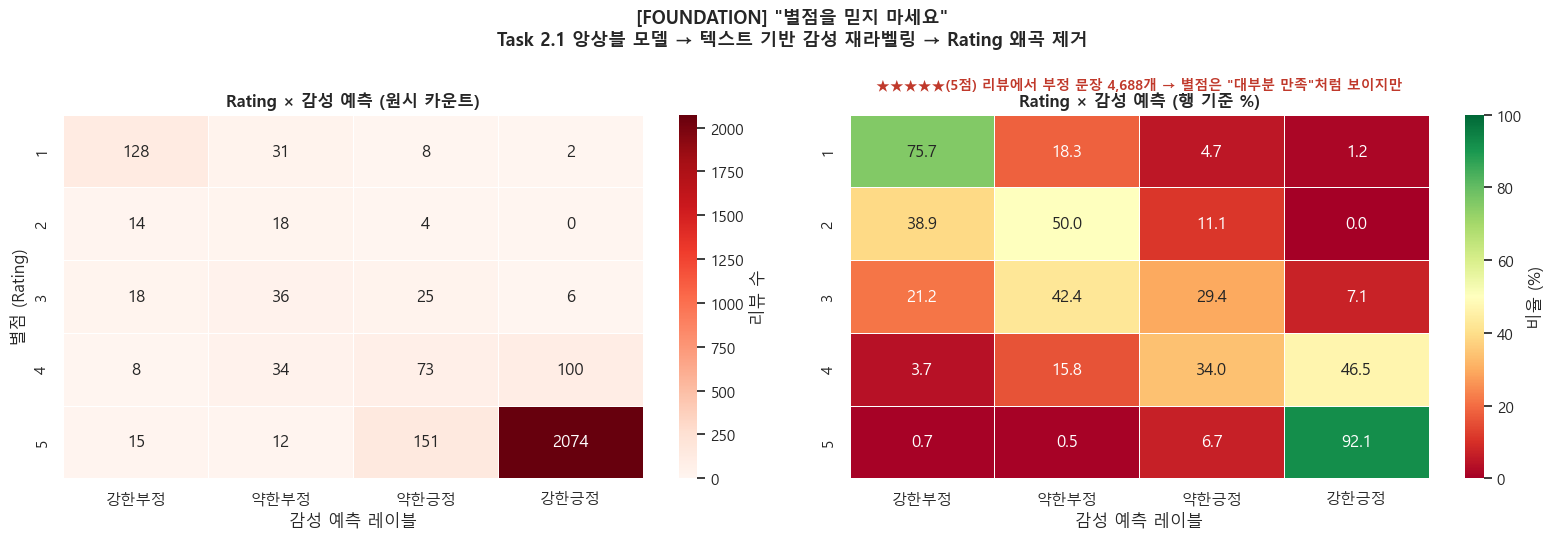

=== Foundation 핵심 수치 ===
리뷰 수준 부정 탐지: 314개
문장 수준으로 내려가면: 5,881개 (20.5%)
5점 리뷰 안 숨겨진 부정 문장: 4,688개
Rating 기반 탐지(1-2점): 205개 vs 모델 탐지: 314개


In [11]:
LABEL_KO_ORDER = ['강한부정', '약한부정', '약한긍정', '강한긍정']

ct = pd.crosstab(df['rating'], df['sentiment_ko'])
ct = ct.reindex(columns=[c for c in LABEL_KO_ORDER if c in ct.columns])
ct_norm = ct.div(ct.sum(axis=1), axis=0) * 100

# 5점 리뷰 안 숨겨진 부정 문장 수
hidden_complaints = ss[(ss['rating'] == 5) & (ss['is_negative'] == True)]
n_hidden = len(hidden_complaints)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# ── 왼쪽: 원시 카운트 히트맵 ──────────────────────────────────────
sns.heatmap(ct, annot=True, fmt='d', cmap='Reds',
            linewidths=0.5, ax=axes[0],
            cbar_kws={'label': '리뷰 수'})
axes[0].set_title('Rating × 감성 예측 (원시 카운트)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('감성 예측 레이블')
axes[0].set_ylabel('별점 (Rating)')

# ── 오른쪽: 행 기준 비율 히트맵 ──────────────────────────────────
ax = axes[1]
sns.heatmap(ct_norm, annot=True, fmt='.1f', cmap='RdYlGn',
            vmin=0, vmax=100, linewidths=0.5, ax=ax,
            cbar_kws={'label': '비율 (%)'})
ax.set_title('Rating × 감성 예측 (행 기준 %)', fontsize=12, fontweight='bold')
ax.set_xlabel('감성 예측 레이블')
ax.set_ylabel('')

# 핵심 수치 강조 (5점 리뷰 오염)
rate5_neg_pct = ct_norm.loc[5, '강한부정':'약한부정'].sum() if 5 in ct_norm.index else 0
ax.text(0.5, 1.07,
        f'★★★★★(5점) 리뷰에서 부정 문장 {n_hidden:,}개 → 별점은 "대부분 만족"처럼 보이지만',
        transform=ax.transAxes, ha='center', fontsize=10,
        color='#c0392b', fontweight='bold')

plt.suptitle('[FOUNDATION] "별점을 믿지 마세요"\n'
             'Task 2.1 앙상블 모델 → 텍스트 기반 감성 재라벨링 → Rating 왜곡 제거',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'slide1_foundation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'=== Foundation 핵심 수치 ===')
print(f'리뷰 수준 부정 탐지: {df["is_negative"].sum():,}개')
print(f'문장 수준으로 내려가면: {ss["is_negative"].sum():,}개 ({ss["is_negative"].sum()/len(ss)*100:.1f}%)')
print(f'5점 리뷰 안 숨겨진 부정 문장: {n_hidden:,}개')
print(f'Rating 기반 탐지(1-2점): {(df["rating"]<=2).sum():,}개 vs 모델 탐지: {df["is_negative"].sum():,}개')

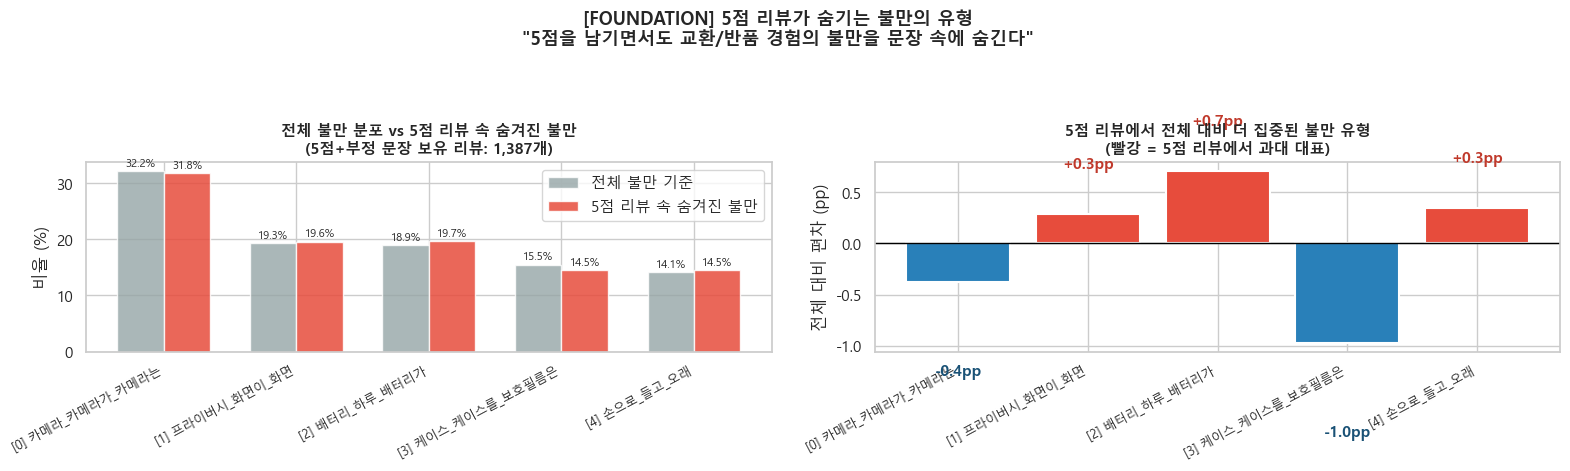

5점 리뷰 + 부정 문장 보유 리뷰: 1,387개
                    전체 불만  5점 속 숨겨진 불만   차이
cluster_name                               
[0] 카메라_카메라가_카메라는    32.2         31.8 -0.4
[1] 프라이버시_화면이_화면     19.3         19.6  0.3
[2] 배터리_하루_배터리가      18.9         19.7  0.7
[3] 케이스_케이스를_보호필름은   15.5         14.5 -1.0
[4] 손으로_들고_오래        14.1         14.5  0.3


In [12]:
# ══════════════════════════════════════════════════════════════════
# FOUNDATION-2: 5점 리뷰가 숨기는 불만의 유형
# ══════════════════════════════════════════════════════════════════
# sentence_sentiments.csv에 이미 rating 컬럼 있음
# → 5점이지만 부정 문장이 있는 리뷰를 직접 식별

five_star_neg_ids = ss[
    (ss['rating'] == 5) & (ss['is_negative'])
]['review_id'].unique()

# cc에서 MAIN_CLUSTERS만 필터 (cc_main은 아래 셀에서 정의되므로 로컬 정의)
_cc_filt = cc[cc['cluster_name'].isin(MAIN_CLUSTERS)]
cc_5star = _cc_filt[_cc_filt['review_id'].isin(five_star_neg_ids)]

cc_all_pct   = _cc_filt['cluster_name'].value_counts(normalize=True).reindex(MAIN_CLUSTERS) * 100
cc_5star_pct = cc_5star['cluster_name'].value_counts(normalize=True).reindex(MAIN_CLUSTERS) * 100

compare = pd.DataFrame({
    '전체 불만': cc_all_pct,
    '5점 속 숨겨진 불만': cc_5star_pct,
}).fillna(0)
compare['차이'] = compare['5점 속 숨겨진 불만'] - compare['전체 불만']

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

ax1 = axes[0]
x = np.arange(len(MAIN_CLUSTERS))
w = 0.35
b1 = ax1.bar(x - w/2, compare['전체 불만'].values, w, label='전체 불만 기준',
             color='#95a5a6', alpha=0.8, edgecolor='white')
b2 = ax1.bar(x + w/2, compare['5점 속 숨겨진 불만'].values, w, label='5점 리뷰 속 숨겨진 불만',
             color='#e74c3c', alpha=0.85, edgecolor='white')
ax1.set_xticks(x)
ax1.set_xticklabels(MAIN_CLUSTERS, rotation=28, ha='right', fontsize=9)
ax1.set_ylabel('비율 (%)')
ax1.set_title(f'전체 불만 분포 vs 5점 리뷰 속 숨겨진 불만\n(5점+부정 문장 보유 리뷰: {len(five_star_neg_ids):,}개)',
              fontsize=11, fontweight='bold')
ax1.legend()
for bar in list(b1) + list(b2):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

ax2 = axes[1]
bar_colors = ['#e74c3c' if v > 0 else '#2980b9' for v in compare['차이'].values]
ax2.bar(range(len(MAIN_CLUSTERS)), compare['차이'].values,
        color=bar_colors, edgecolor='white', linewidth=1.5)
ax2.axhline(0, color='black', linewidth=1)
ax2.set_xticks(range(len(MAIN_CLUSTERS)))
ax2.set_xticklabels(MAIN_CLUSTERS, rotation=28, ha='right', fontsize=9)
ax2.set_ylabel('전체 대비 편차 (pp)')
ax2.set_title('5점 리뷰에서 전체 대비 더 집중된 불만 유형\n(빨강 = 5점 리뷰에서 과대 대표)',
              fontsize=11, fontweight='bold')
for i, v in enumerate(compare['차이'].values):
    ax2.text(i, v + (0.4 if v >= 0 else -0.8), f'{v:+.1f}pp',
             ha='center', va='bottom' if v >= 0 else 'top', fontsize=11, fontweight='bold',
             color='#c0392b' if v > 0 else '#1a5276')

plt.suptitle('[FOUNDATION] 5점 리뷰가 숨기는 불만의 유형\n'
             '"5점을 남기면서도 교환/반품 경험의 불만을 문장 속에 숨긴다"',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'slide1b_hidden_complaint_types.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'5점 리뷰 + 부정 문장 보유 리뷰: {len(five_star_neg_ids):,}개')
print(compare.round(1).to_string())

---
## [WHAT] 불만의 구조 — Slide 2

`sentence_sentiments.csv` 부정 문장을 직접 클러스터링한 결과를 시각화합니다.

(TF-IDF + UMAP 30D + KMeans k=6 + 키워드 자동 레이블링)

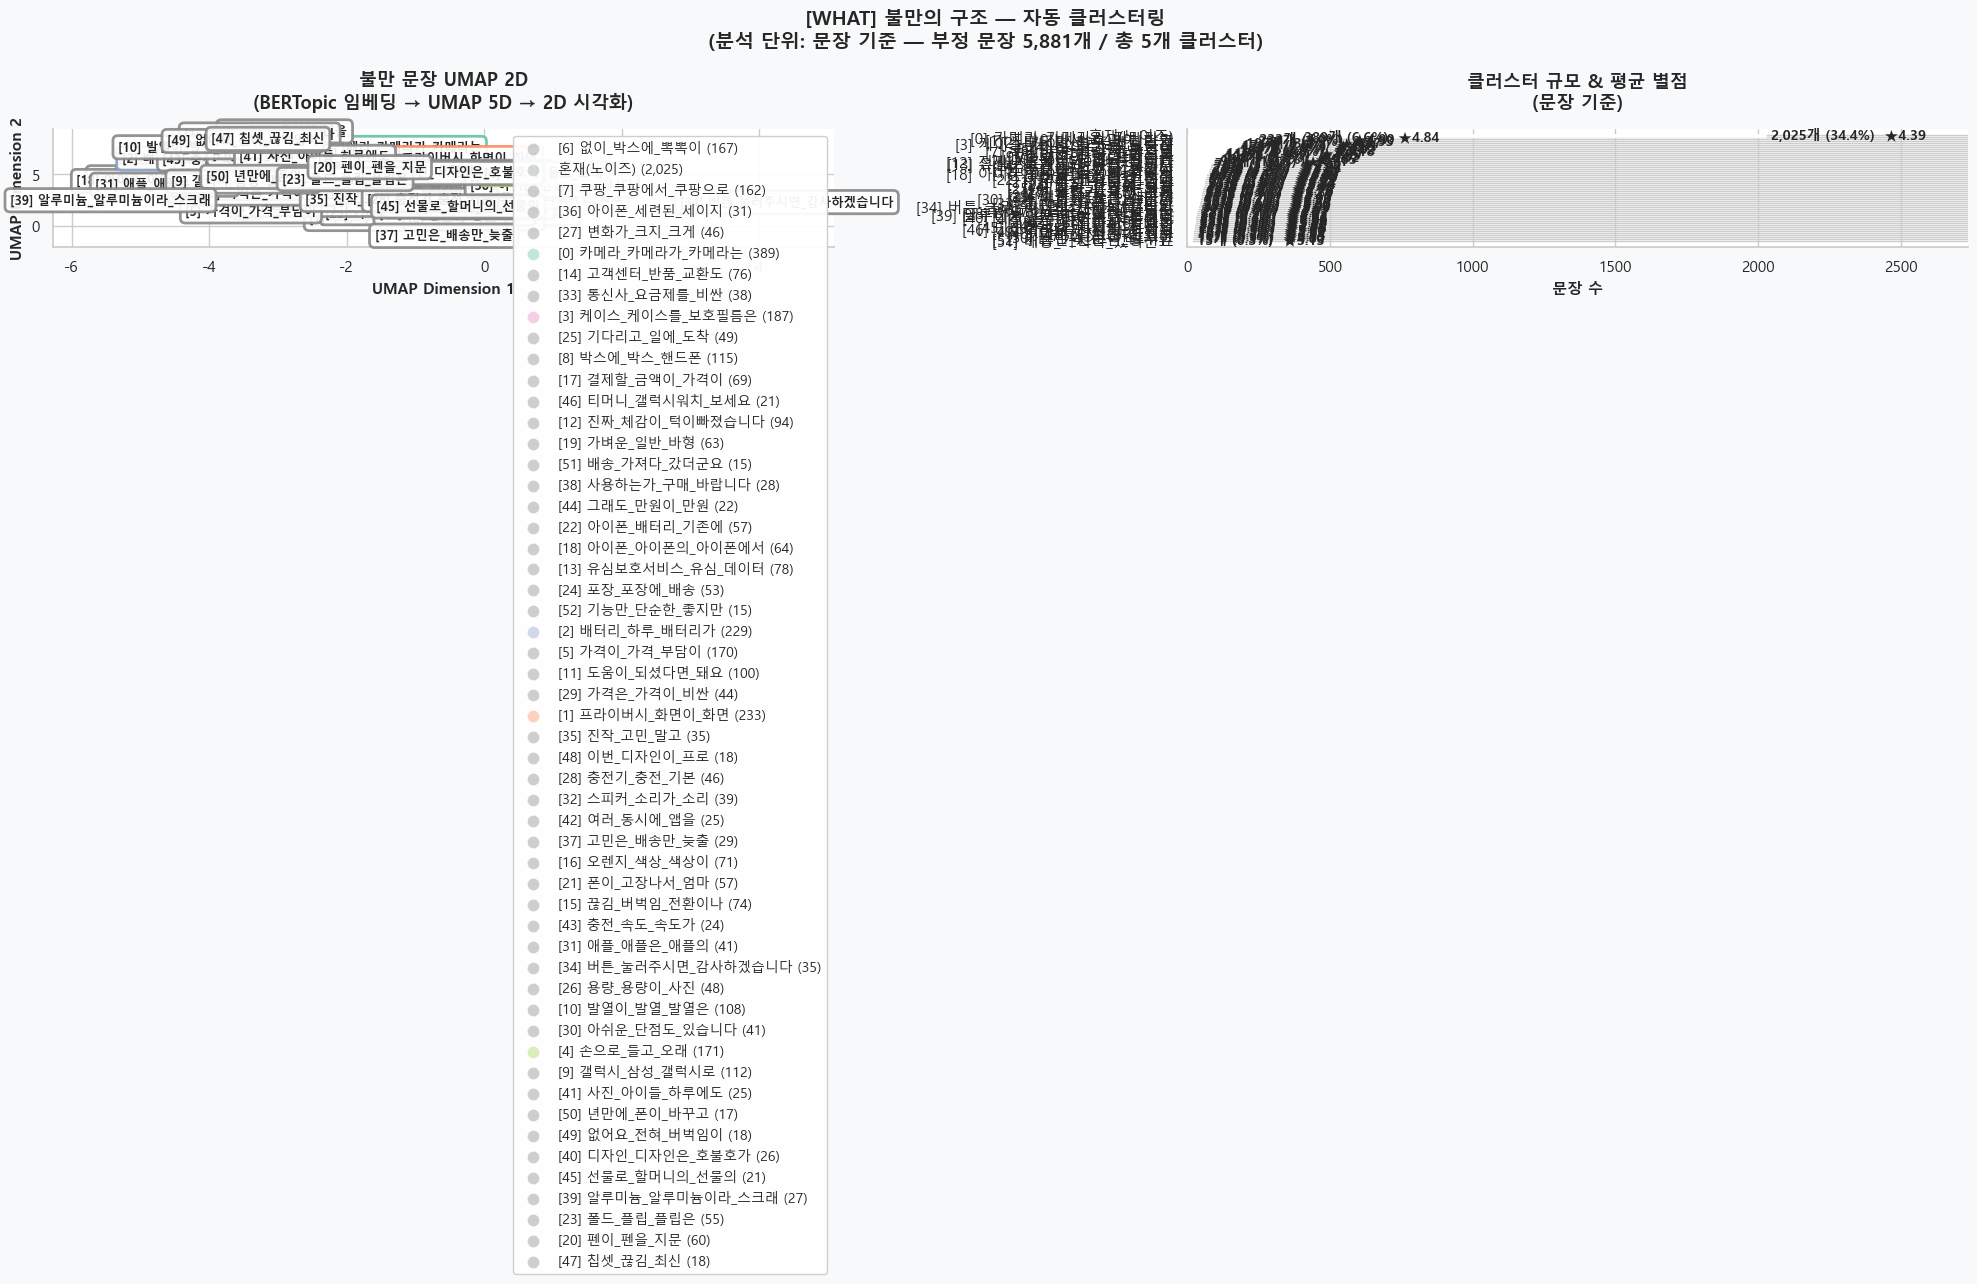


📌 [WHAT-1] 분석 단위: 문장 기준 (5,881개 부정 문장)

📊 클러스터 요약 (CSV 저장됨):


,Review_Count,Sentence_Count,Avg_Rating
cluster_name,,,
[0] 카메라_카메라가_카메라는,290,389,4.84
[10] 발열이_발열_발열은,89,108,4.82
[11] 도움이_되셨다면_돼요,91,100,4.65
[12] 진짜_체감이_턱이빠졌습니다,82,94,4.71
[13] 유심보호서비스_유심_데이터,51,78,4.51
[14] 고객센터_반품_교환도,60,76,2.42
[15] 끊김_버벅임_전환이나,71,74,4.92
[16] 오렌지_색상_색상이,54,71,4.89
[17] 결제할_금액이_가격이,62,69,4.61


In [17]:
# ══════════════════════════════════════════════════════════════════
# [WHAT-1] UMAP 2D + 클러스터 규모 (발표용 개선 + 단위 명시)
# ══════════════════════════════════════════════════════════════════
has_umap = ('umap_x' in cc.columns and cc['umap_x'].notna().any())

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.patch.set_facecolor('#f8f9fa')

# ── 왼쪽: UMAP 2D 산점도 (발표용 스타일) ──────────────────────────────────
ax1 = axes[0]
if has_umap:
    for cname in cc['cluster_name'].unique():
        mask = cc['cluster_name'] == cname
        color = CLUSTER_COLORS.get(cname, '#888888')
        ax1.scatter(
            cc.loc[mask, 'umap_x'], cc.loc[mask, 'umap_y'],
            c=color, label=f'{cname} ({mask.sum():,})',
            alpha=0.4, s=12, edgecolors='white', linewidth=0.5,
        )
        if mask.sum() > 10:
            cx = cc.loc[mask, 'umap_x'].mean()
            cy = cc.loc[mask, 'umap_y'].mean()
            ax1.annotate(
                cname, (cx, cy), fontsize=9, fontweight='bold', ha='center',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                          alpha=0.9, edgecolor=color, linewidth=2),
            )
    ax1.set_title('불만 문장 UMAP 2D\n(BERTopic 임베딩 → UMAP 5D → 2D 시각화)', 
                  fontsize=13, fontweight='bold', pad=15)
    ax1.legend(markerscale=2.5, fontsize=10, loc='best', framealpha=0.95, edgecolor='#ccc')
    ax1.set_xlabel('UMAP Dimension 1', fontsize=11, fontweight='bold')
    ax1.set_ylabel('UMAP Dimension 2', fontsize=11, fontweight='bold')
    ax1.set_facecolor('#ffffff')
else:
    ax1.text(0.5, 0.5, 'UMAP 미계산', transform=ax1.transAxes, ha='center')

# ── 오른쪽: 클러스터 규모 bar (발표용) ──────────────────────────────────────
ax2 = axes[1]
cluster_sizes = (
    cc.groupby('cluster_name')
    .agg(count=('cluster', 'size'), avg_rating=('rating', 'mean'))
    .sort_values('count', ascending=True)
)
bar_colors = [CLUSTER_COLORS.get(n, '#888') for n in cluster_sizes.index]
bars = ax2.barh(
    cluster_sizes.index, cluster_sizes['count'],
    color=bar_colors, edgecolor='white', linewidth=2, height=0.7
)
for bar, (cname, row) in zip(bars, cluster_sizes.iterrows()):
    ax2.text(
        bar.get_width() + 20,
        bar.get_y() + bar.get_height() / 2,
        f"{int(row['count']):,}개 ({row['count']/len(cc)*100:.1f}%)  ★{row['avg_rating']:.2f}",
        va='center', fontsize=10, fontweight='bold',
    )
ax2.set_title('클러스터 규모 & 평균 별점\n(문장 기준)', 
              fontsize=13, fontweight='bold', pad=15)
ax2.set_xlabel('문장 수', fontsize=11, fontweight='bold')
ax2.set_xlim(0, cluster_sizes['count'].max() * 1.35)
ax2.set_facecolor('#ffffff')

plt.suptitle('[WHAT] 불만의 구조 — 자동 클러스터링\n(분석 단위: 문장 기준 — 부정 문장 {0:,}개 / 총 {1}개 클러스터)'.format(len(cc), len(MAIN_CLUSTERS)),
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig(OUT_DIR / 'slide2a_what_umap.png', dpi=200, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()

# CSV 저장 (Slide 2a)
print(f'\n📌 [WHAT-1] 분석 단위: 문장 기준 ({len(cc):,}개 부정 문장)')
cluster_summary = cc.groupby('cluster_name').agg({
    'review_id': 'nunique',
    'sentence': 'count',
    'rating': 'mean'
}).rename(columns={
    'review_id': 'Review_Count',
    'sentence': 'Sentence_Count',
    'rating': 'Avg_Rating'
}).round(2)
cluster_summary.to_csv(OUT_DIR / 'cluster_summary.csv', encoding='utf-8-sig')
print('\n📊 클러스터 요약 (CSV 저장됨):')
display(cluster_summary)

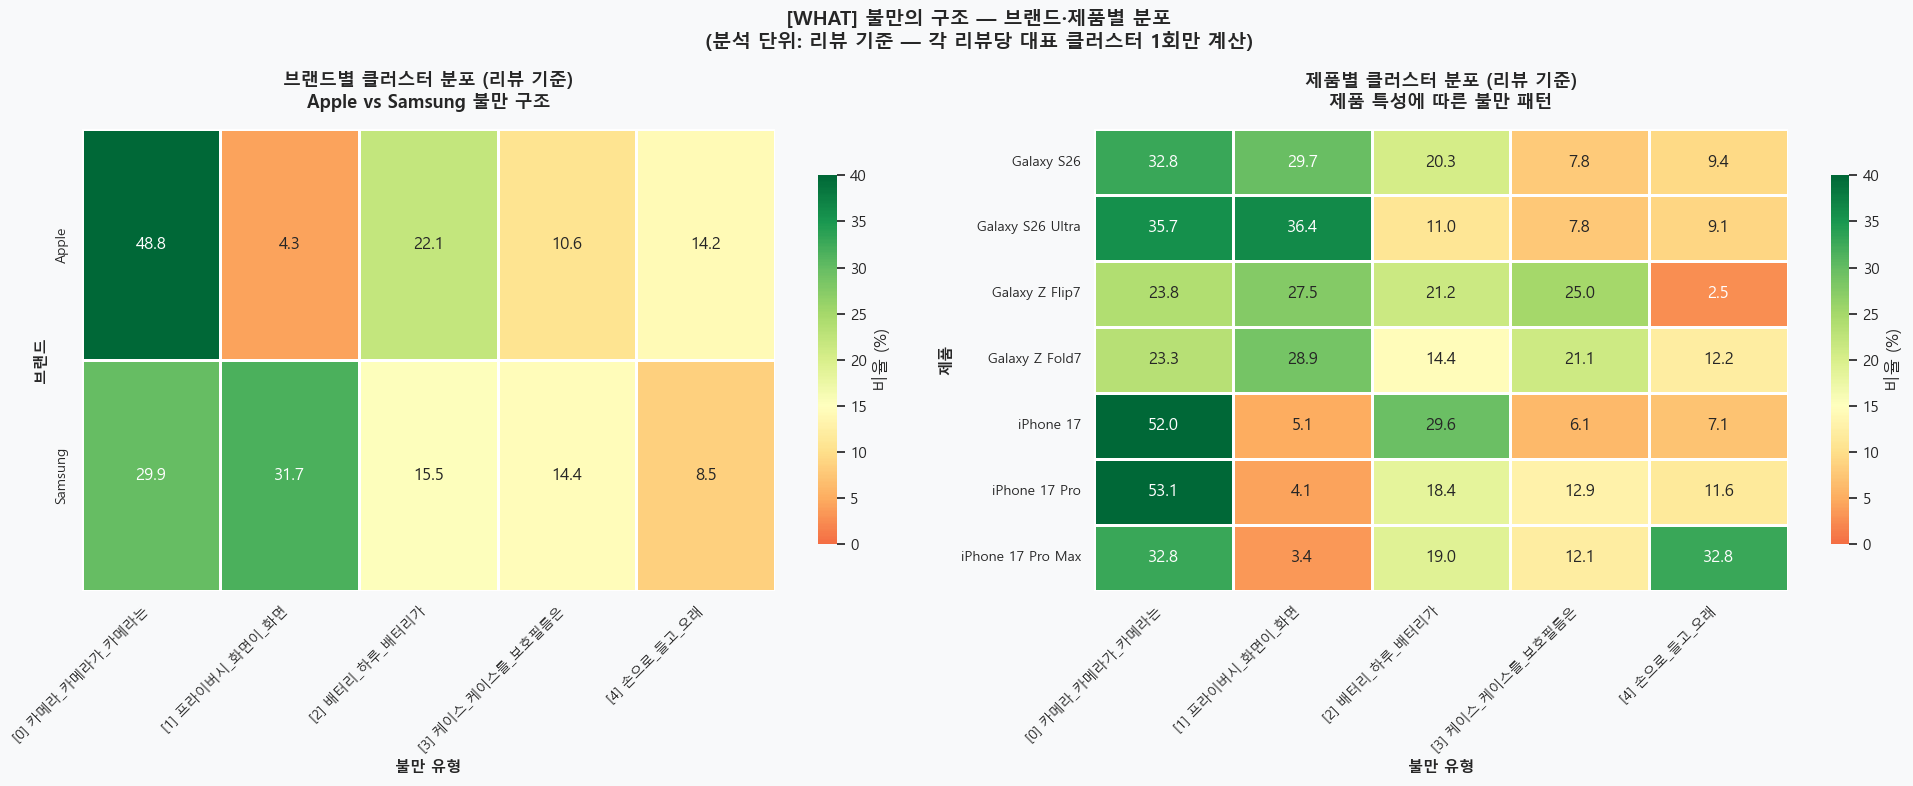


📌 [WHAT-2] 분석 단위: 리뷰 기준 (691개 리뷰)

📊 브랜드×클러스터 분포 (리뷰 기준):


cluster_name,[0] 카메라_카메라가_카메라는,[1] 프라이버시_화면이_화면,[2] 배터리_하루_배터리가,[3] 케이스_케이스를_보호필름은,[4] 손으로_들고_오래
brand,,,,,
Apple,48.8,4.3,22.1,10.6,14.2
Samsung,29.9,31.7,15.5,14.4,8.5



📊 제품×클러스터 분포 (리뷰 기준):


cluster_name,[0] 카메라_카메라가_카메라는,[1] 프라이버시_화면이_화면,[2] 배터리_하루_배터리가,[3] 케이스_케이스를_보호필름은,[4] 손으로_들고_오래
product_label,,,,,
Galaxy S26,32.8,29.7,20.3,7.8,9.4
Galaxy S26 Ultra,35.7,36.4,11.0,7.8,9.1
Galaxy Z Flip7,23.8,27.5,21.2,25.0,2.5
Galaxy Z Fold7,23.3,28.9,14.4,21.1,12.2
iPhone 17,52.0,5.1,29.6,6.1,7.1
iPhone 17 Pro,53.1,4.1,18.4,12.9,11.6
iPhone 17 Pro Max,32.8,3.4,19.0,12.1,32.8


In [18]:
# ══════════════════════════════════════════════════════════════════
# [WHAT-2] 브랜드·제품별 불만 클러스터 분포 (리뷰 기준 + 발표용 개선)
# ══════════════════════════════════════════════════════════════════

# 리뷰 기준 대표 클러스터 계산 (각 리뷰당 가장 많은 불만 클러스터 1회만 계산)
cc_main = cc[cc['cluster_name'].isin(MAIN_CLUSTERS)].copy()
review_level = cc_main.groupby('review_id').agg({
    'cluster_name': lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0],
    'brand': 'first',
    'product_label': 'first',
    'rating': 'first'
}).reset_index()

brand_cluster_review = (
    pd.crosstab(review_level['brand'], review_level['cluster_name'], normalize='index') * 100
).reindex(columns=MAIN_CLUSTERS)

prod_cluster_review = (
    pd.crosstab(review_level['product_label'], review_level['cluster_name'], normalize='index') * 100
).reindex(columns=MAIN_CLUSTERS)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.patch.set_facecolor('#f8f9fa')

# 왼쪽: 브랜드별 클러스터 분포 (히트맵)
sns.heatmap(brand_cluster_review, annot=True, fmt='.1f', cmap='RdYlGn', center=15,
            vmin=0, vmax=40, linewidths=2, linecolor='white', ax=axes[0],
            cbar_kws={'label': '비율 (%)', 'shrink': 0.8}, 
            square=False, cbar_ax=None)
axes[0].set_title('브랜드별 클러스터 분포 (리뷰 기준)\nApple vs Samsung 불만 구조', 
                  fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('불만 유형', fontsize=11, fontweight='bold')
axes[0].set_ylabel('브랜드', fontsize=11, fontweight='bold')
axes[0].set_facecolor('#ffffff')
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right', fontsize=10)
plt.setp(axes[0].get_yticklabels(), fontsize=10)

# 오른쪽: 제품별 클러스터 분포 (히트맵)
sns.heatmap(prod_cluster_review, annot=True, fmt='.1f', cmap='RdYlGn', center=15,
            vmin=0, vmax=40, linewidths=2, linecolor='white', ax=axes[1],
            cbar_kws={'label': '비율 (%)', 'shrink': 0.8},
            square=False, cbar_ax=None)
axes[1].set_title('제품별 클러스터 분포 (리뷰 기준)\n제품 특성에 따른 불만 패턴', 
                  fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('불만 유형', fontsize=11, fontweight='bold')
axes[1].set_ylabel('제품', fontsize=11, fontweight='bold')
axes[1].set_facecolor('#ffffff')
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=10)
plt.setp(axes[1].get_yticklabels(), fontsize=10)

plt.suptitle('[WHAT] 불만의 구조 — 브랜드·제품별 분포\n(분석 단위: 리뷰 기준 — 각 리뷰당 대표 클러스터 1회만 계산)',
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig(OUT_DIR / 'slide2b_what_brand_product.png', dpi=200, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()

# CSV 저장
brand_cluster_review.to_csv(OUT_DIR / 'brand_cluster_distribution.csv', encoding='utf-8-sig')
prod_cluster_review.to_csv(OUT_DIR / 'product_cluster_distribution.csv', encoding='utf-8-sig')

print(f'\n📌 [WHAT-2] 분석 단위: 리뷰 기준 ({len(review_level):,}개 리뷰)')  
print('\n📊 브랜드×클러스터 분포 (리뷰 기준):')
display(brand_cluster_review.round(1))
print('\n📊 제품×클러스터 분포 (리뷰 기준):')
display(prod_cluster_review.round(1))

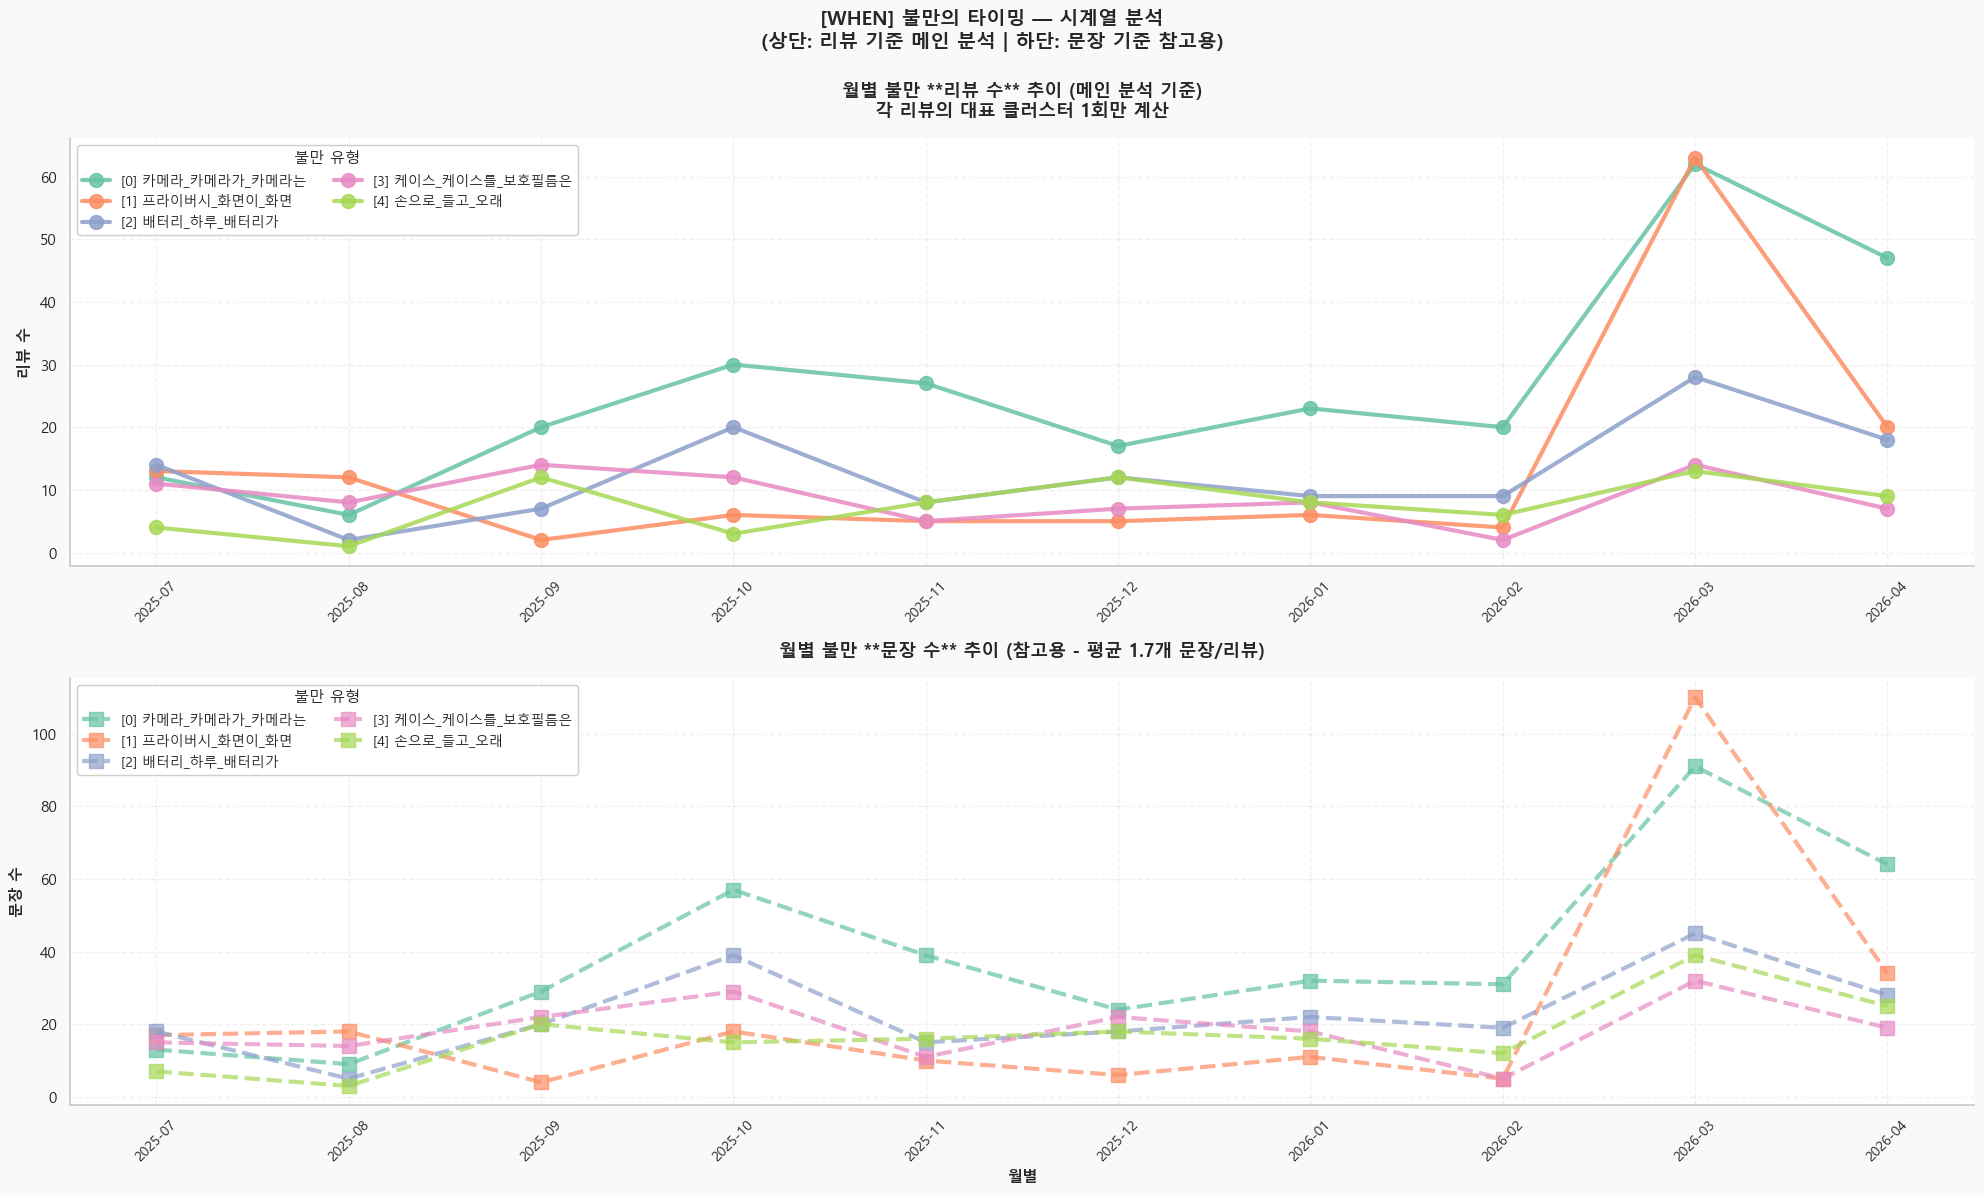


📌 [WHEN] 분석 단위: 리뷰 기준 (메인) + 문장 기준 (참고)
   - 리뷰 수: 10건  |  문장 수: 10건
   - 평균: 1.7개 문장/리뷰

📊 월별 불만 리뷰 추이 (메인):


cluster_name,[0] 카메라_카메라가_카메라는,[1] 프라이버시_화면이_화면,[2] 배터리_하루_배터리가,[3] 케이스_케이스를_보호필름은,[4] 손으로_들고_오래
review_month,,,,,
2025-07,12,13,14,11,4
2025-08,6,12,2,8,1
2025-09,20,2,7,14,12
2025-10,30,6,20,12,3
2025-11,27,5,8,5,8
2025-12,17,5,12,7,12
2026-01,23,6,9,8,8
2026-02,20,4,9,2,6
2026-03,62,63,28,14,13



📊 월별 불만 문장 추이 (참고):


cluster_name,[0] 카메라_카메라가_카메라는,[1] 프라이버시_화면이_화면,[2] 배터리_하루_배터리가,[3] 케이스_케이스를_보호필름은,[4] 손으로_들고_오래
review_month,,,,,
2025-07,13,17,18,15,7
2025-08,9,18,5,14,3
2025-09,29,4,20,22,20
2025-10,57,18,39,29,15
2025-11,39,10,15,11,16
2025-12,24,6,18,22,18
2026-01,32,11,22,18,16
2026-02,31,5,19,5,12
2026-03,91,110,45,32,39


In [19]:
# ══════════════════════════════════════════════════════════════════
# [WHEN-1] Option B: 시계열 분석 (리뷰 기준 + 문장 기준 양쪽)
# ══════════════════════════════════════════════════════════════════

# 데이터 병합 및 준비
cc_main = cc[cc['cluster_name'].isin(MAIN_CLUSTERS)].copy()
cc_merged = cc_main.merge(
    df[['reviewId', 'review_month']].drop_duplicates(subset=['reviewId']),
    on='reviewId', how='left'
)

# ── 1단계: 리뷰 기준 시계열 (메인) ──
review_monthly = cc_merged.groupby('review_id').agg({
    'cluster_name': lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0],
    'review_month': 'first'
})
monthly_by_review = (
    pd.crosstab(review_monthly['review_month'], review_monthly['cluster_name'])
    .reindex(columns=MAIN_CLUSTERS)
    .fillna(0).astype(int)
)

# ── 2단계: 문장 기준 시계열 (참고) ──
monthly_by_sentence = (
    pd.crosstab(cc_merged['review_month'], cc_merged['cluster_name'])
    .reindex(columns=MAIN_CLUSTERS)
    .fillna(0).astype(int)
)

# ── 시각화 (2개 차트) ──
fig, axes = plt.subplots(2, 1, figsize=(20, 12))
fig.patch.set_facecolor('#f8f9fa')

# 상단: 리뷰 기준 (메인 분석)
ax1 = axes[0]
for col in monthly_by_review.columns:
    ax1.plot(range(len(monthly_by_review)), monthly_by_review[col].values,
            marker='o', linewidth=3, markersize=10, label=col,
            color=CLUSTER_COLORS.get(col, '#888'), alpha=0.85)
ax1.set_title('월별 불만 **리뷰 수** 추이 (메인 분석 기준)\n각 리뷰의 대표 클러스터 1회만 계산',
              fontsize=13, fontweight='bold', pad=15)
ax1.set_ylabel('리뷰 수', fontsize=11, fontweight='bold')
ax1.set_xticks(range(len(monthly_by_review)))
ax1.set_xticklabels([str(m) for m in monthly_by_review.index], fontsize=10, rotation=45)
ax1.legend(title='불만 유형', title_fontsize=11, fontsize=10, loc='best', framealpha=0.95, ncol=2)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_facecolor('#ffffff')

# 하단: 문장 기준 (비교용)
ax2 = axes[1]
for col in monthly_by_sentence.columns:
    ax2.plot(range(len(monthly_by_sentence)), monthly_by_sentence[col].values,
            marker='s', linewidth=3, markersize=10, label=col, linestyle='--',
            color=CLUSTER_COLORS.get(col, '#888'), alpha=0.7)
avg_per_review = len(cc_merged) / len(review_monthly)
ax2.set_title('월별 불만 **문장 수** 추이 (참고용 - 평균 {:.1f}개 문장/리뷰)'.format(avg_per_review),
              fontsize=13, fontweight='bold', pad=15)
ax2.set_xlabel('월별', fontsize=11, fontweight='bold')
ax2.set_ylabel('문장 수', fontsize=11, fontweight='bold')
ax2.set_xticks(range(len(monthly_by_sentence)))
ax2.set_xticklabels([str(m) for m in monthly_by_sentence.index], fontsize=10, rotation=45)
ax2.legend(title='불만 유형', title_fontsize=11, fontsize=10, loc='best', framealpha=0.95, ncol=2)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_facecolor('#ffffff')

plt.suptitle('[WHEN] 불만의 타이밍 — 시계열 분석\n(상단: 리뷰 기준 메인 분석 | 하단: 문장 기준 참고용)',
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(OUT_DIR / 'slide3_when_timeseries.png', dpi=200, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()

# CSV 저장
monthly_by_review.to_csv(OUT_DIR / 'timeseries_by_review.csv', encoding='utf-8-sig')
monthly_by_sentence.to_csv(OUT_DIR / 'timeseries_by_sentence.csv', encoding='utf-8-sig')

print(f'\n📌 [WHEN] 분석 단위: 리뷰 기준 (메인) + 문장 기준 (참고)')
print(f'   - 리뷰 수: {len(monthly_by_review):,}건  |  문장 수: {len(monthly_by_sentence):,}건')
print(f'   - 평균: {avg_per_review:.1f}개 문장/리뷰')
print('\n📊 월별 불만 리뷰 추이 (메인):')
display(monthly_by_review)
print('\n📊 월별 불만 문장 추이 (참고):')
display(monthly_by_sentence)

---
## [WHEN] 불만의 타이밍 — Slide 3

구매 코호트 정의 → 월별 시계열 → 배송 vs 카메라 비교

In [16]:
# ── WHEN-1: 코호트 정의 ──────────────────────────────────────────
# 제품별 '첫 리뷰 날짜'를 D+0 기준점으로 사용 (공식 출시일 미활용)
first_review_dt = df.groupby('product_name')['reviewAt_dt'].min().to_dict()
df['release_date'] = df['product_name'].map(first_review_dt)
df['days_since_release'] = (df['reviewAt_dt'] - df['release_date']).dt.days

def assign_cohort(d):
    if pd.isna(d) or d < 0:
        return '출시 전'
    if d <= 30:
        return 'D+0~30 (얼리어답터)'
    if d <= 90:
        return 'D+31~90 (초기다수)'
    return 'D+91+ (후기다수)'

df['cohort'] = df['days_since_release'].apply(assign_cohort)
df_cohort = df[df['cohort'] != '출시 전'].copy()

print('제품별 D+0 기준점 (첫 리뷰 날짜):')
for prod, dt in sorted(first_review_dt.items()):
    print(f'  {PRODUCT_LABELS.get(prod, prod):<22}: {dt.strftime("%Y-%m-%d")}')

print(f'\n코호트 분포:')
print(df_cohort['cohort'].value_counts().to_string())

print(f'\n코호트별 평균 평점:')
for cohort in COHORT_ORDER:
    sub = df_cohort[df_cohort['cohort'] == cohort]
    print(f'  {cohort}: 평균 {sub["rating"].mean():.2f}  '
          f'부정률 {sub["is_negative"].mean()*100:.1f}%  (n={len(sub)})')

제품별 D+0 기준점 (첫 리뷰 날짜):
  Galaxy S26            : 2026-03-05
  Galaxy S26 Ultra      : 2026-03-04
  Galaxy Z Flip7        : 2025-07-20
  Galaxy Z Fold7        : 2025-07-20
  iPhone 17             : 2025-09-20
  iPhone 17 Pro         : 2025-09-19
  iPhone 17 Pro Max     : 2025-09-19

코호트 분포:
cohort
D+0~30 (얼리어답터)    1117
D+91+ (후기다수)       879
D+31~90 (초기다수)     761

코호트별 평균 평점:
  D+0~30 (얼리어답터): 평균 4.64  부정률 9.8%  (n=1117)
  D+31~90 (초기다수): 평균 4.53  부정률 11.3%  (n=761)
  D+91+ (후기다수): 평균 4.53  부정률 13.5%  (n=879)


In [ ]:
# ══════════════════════════════════════════════════════════════════
# WHEN-3: 브랜드별 분리 시계열 — 2026-03 스파이크의 진실
# ══════════════════════════════════════════════════════════════════

_cc_m = cc[cc['cluster_name'].isin(MAIN_CLUSTERS)].copy()
# cc.review_id (int) ↔ df.reviewId (int) 키 차이 주의
_cc_when_tmp = _cc_m.merge(
    df[['reviewId', 'reviewAt_dt']],
    left_on='review_id', right_on='reviewId', how='left'
)
_cc_when_tmp['review_month_str'] = _cc_when_tmp['reviewAt_dt'].dt.to_period('M').astype(str)
_cc_when_tmp = _cc_when_tmp[_cc_when_tmp['review_month_str'].notna()].copy()

fig, axes = plt.subplots(2, 1, figsize=(16, 11))

brand_configs = [
    ('Apple',   '#4A90D9', 'iPhone 17 시리즈 출시: 2025-09'),
    ('Samsung', '#E85D5D', 'Galaxy S26/S26U 출시: 2026-03 → 2026-03 스파이크 = 삼성 D+0 얼리어답터 물량'),
]

for ax, (brand, brand_color, note) in zip(axes, brand_configs):
    brand_cc = _cc_when_tmp[_cc_when_tmp['brand'] == brand]
    brand_monthly = (
        brand_cc.groupby(['review_month_str', 'cluster_name'])
        .size().unstack(fill_value=0)
        .sort_index()
    )
    brand_monthly = brand_monthly.reindex(
        columns=[c for c in MAIN_CLUSTERS if c in brand_monthly.columns]
    )
    if brand_monthly.empty:
        ax.text(0.5, 0.5, f'{brand} 데이터 없음', transform=ax.transAxes, ha='center')
        continue

    x = np.arange(len(brand_monthly))
    month_labels = list(brand_monthly.index)
    bottom = np.zeros(len(brand_monthly))
    for cname in brand_monthly.columns:
        ax.bar(x, brand_monthly[cname].values, bottom=bottom,
               label=cname, color=CLUSTER_COLORS.get(cname, '#888'),
               alpha=0.85, edgecolor='white', linewidth=0.5)
        bottom += brand_monthly[cname].values

    ax.set_xticks(x)
    ax.set_xticklabels(month_labels, rotation=40, ha='right')
    ax.set_title(f'{brand} — 월별 불만 트렌드', fontsize=12, fontweight='bold', color=brand_color)
    ax.set_ylabel('불만 문장 수')
    ax.text(0.01, 0.97, note, transform=ax.transAxes, fontsize=9,
            color='#c0392b' if brand == 'Samsung' else '#1a5276',
            va='top', fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='#ccc', boxstyle='round,pad=0.3'))

    if brand == 'Apple':
        ax.legend(loc='upper right', ncol=3, fontsize=8)

    if bottom.max() > 0:
        peak_idx = int(bottom.argmax())
        ax.annotate(f'D+0 피크\n{month_labels[peak_idx]}',
                    xy=(peak_idx, bottom[peak_idx]),
                    xytext=(max(0, peak_idx - 2), bottom[peak_idx] * 0.82),
                    fontsize=8, fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color='black', lw=1.2))

plt.suptitle('[WHEN] 2026-03 전체 스파이크의 정체\n'
             'Samsung S26 출시 D+0 불만 급증 — iPhone은 안정적, 두 브랜드의 타임라인이 다르다',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'slide3b_when_brand_split.png', dpi=150, bbox_inches='tight')
plt.show()

print('→ 전체 차트의 2026-03 스파이크 = Samsung S26/S26U 출시 D+0 얼리어답터 불만 집중')
print('→ "카메라 시한폭탄"이 아니라 신제품 출시 초기 불만 패턴')

In [ ]:
# ── WHEN-2: 월별 불만 트렌드 + 배송 vs 카메라 대비 ────────────────

# 클러스터 할당에 날짜 정보 병합
cc_when = cc_main.merge(
    df[['reviewId', 'reviewAt_dt', 'cohort', 'days_since_release']],
    on='reviewId', how='left'
)
cc_when['review_month_str'] = cc_when['reviewAt_dt'].dt.to_period('M').astype(str)
cc_when = cc_when[cc_when['review_month_str'].notna()].copy()

# 월별 클러스터별 집계
monthly = (
    cc_when.groupby(['review_month_str', 'cluster_name'])
    .size().unstack(fill_value=0)
    .sort_index()
)
monthly = monthly.reindex(columns=[c for c in MAIN_CLUSTERS if c in monthly.columns])

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# ── 상단: 전체 월별 stacked bar ────────────────────────────────────
ax1 = axes[0]
x = np.arange(len(monthly))
month_labels = list(monthly.index)
bottom = np.zeros(len(monthly))

for cname in monthly.columns:
    ax1.bar(x, monthly[cname].values, bottom=bottom,
            label=cname, color=CLUSTER_COLORS.get(cname, '#888'),
            alpha=0.85, edgecolor='white', linewidth=0.5)
    bottom += monthly[cname].values

ax1.set_xticks(x)
ax1.set_xticklabels(month_labels, rotation=45, ha='right')
ax1.set_title('월별 불만 트렌드 — 전체 클러스터 (혼재 제외)', fontsize=12, fontweight='bold')
ax1.set_ylabel('불만 문장 수')
ax1.legend(loc='upper left', ncol=2, fontsize=9)

# 2026-03 폭발 표시
if '2026-03' in month_labels:
    idx_peak = month_labels.index('2026-03')
    ax1.axvline(idx_peak, color='red', linestyle='--', linewidth=1.8, alpha=0.7)
    ax1.text(idx_peak + 0.15, ax1.get_ylim()[1] * 0.92,
             '2026-03\n전 클러스터\n동시 폭발', fontsize=9, color='red', fontweight='bold')

# ── 하단: 배송 vs 카메라 꺾은선 대비 ─────────────────────────────
ax2 = axes[1]

if delivery_col in monthly.columns and camera_col in monthly.columns:
    ax2.plot(x, monthly[delivery_col].values,
             color=CLUSTER_COLORS[delivery_col], linewidth=2.5,
             marker='o', markersize=5, label=delivery_col)
    ax2.plot(x, monthly[camera_col].values,
             color=CLUSTER_COLORS[camera_col], linewidth=2.5,
             marker='s', markersize=5, label=camera_col)
    ax2.fill_between(x, monthly[delivery_col].values,
                     alpha=0.12, color=CLUSTER_COLORS[delivery_col])
    ax2.fill_between(x, monthly[camera_col].values,
                     alpha=0.12, color=CLUSTER_COLORS[camera_col])

    # 피크 지점 표시
    peak_d_idx = monthly[delivery_col].values.argmax()
    peak_c_idx = monthly[camera_col].values.argmax()
    ax2.annotate(
        f'배송 피크\n{month_labels[peak_d_idx]}',
        xy=(peak_d_idx, monthly[delivery_col].values[peak_d_idx]),
        xytext=(peak_d_idx - 1.5, monthly[delivery_col].values[peak_d_idx] * 1.12),
        fontsize=9, color=CLUSTER_COLORS[delivery_col], fontweight='bold',
        arrowprops=dict(arrowstyle='->', color=CLUSTER_COLORS[delivery_col]),
    )
    ax2.annotate(
        f'카메라 폭발\n{month_labels[peak_c_idx]}\n(4.7× 급증)',
        xy=(peak_c_idx, monthly[camera_col].values[peak_c_idx]),
        xytext=(peak_c_idx - 2.5, monthly[camera_col].values[peak_c_idx] * 1.08),
        fontsize=9, color=CLUSTER_COLORS[camera_col], fontweight='bold',
        arrowprops=dict(arrowstyle='->', color=CLUSTER_COLORS[camera_col]),
    )

ax2.set_xticks(x)
ax2.set_xticklabels(month_labels, rotation=45, ha='right')
ax2.set_title('배송 불만 vs 카메라 불만 — 폭발 시점 비교\n'
              '배송: 출시 직후 피크 → 출시 초기 물류 문제  |  카메라: D+150+ 시한폭탄',
              fontsize=11, fontweight='bold')
ax2.set_ylabel('불만 문장 수')
ax2.legend(fontsize=10)

plt.suptitle('[WHEN] 불만의 타이밍 — 배송과 카메라는 전혀 다른 패턴',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'slide3_when_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

# 핵심 수치 출력
if camera_col in monthly.columns:
    cam_early   = monthly[camera_col].head(3).mean()
    cam_peak    = monthly[camera_col].max()
    peak_month  = monthly[camera_col].idxmax()
    print(f'카메라 불만: 초기(첫 3개월) 월평균 {cam_early:.0f}건 → {peak_month} {cam_peak:.0f}건 ({cam_peak/cam_early if cam_early>0 else 0:.1f}배 증가)')

---
## [WHO] 소비자 세그먼트 — Slide 4

이메일 도메인 = 디지털 라이프스타일 프록시 (Naver/Gmail/카카오/네이트)

In [ ]:
# ── WHO-1: 이메일 도메인 파싱 ─────────────────────────────────────
def extract_email_domain(member_str):
    if not isinstance(member_str, str):
        return 'unknown'
    # member 컬럼: {'type': 'USER', 'name': '이*연', 'email': 'yyo***@gmail.com'}
    m = re.search(r"'email':\s*'([^']+)'", member_str)
    if not m:
        return 'unknown'
    email = m.group(1)
    return email.split('@')[-1].lower() if '@' in email else 'unknown'

def group_domain(domain):
    if 'naver.com' in domain:                                    return '네이버'
    if 'gmail.com' in domain:                                    return 'Gmail'
    if any(d in domain for d in ('hanmail.net', 'daum.net', 'kakao.com')): return '카카오'
    if 'nate.com' in domain:                                     return '네이트'
    if any(d in domain for d in ('icloud.com', 'me.com')):       return 'iCloud'
    if domain == 'unknown':                                       return '미확인'
    return '기타'

df['email_domain']  = df['member'].apply(extract_email_domain)
df['domain_group']  = df['email_domain'].apply(group_domain)

MAIN_DOMAIN_GROUPS = ['네이버', 'Gmail', '카카오', '네이트']
DOMAIN_COLORS = {
    '네이버': '#03C75A',
    'Gmail':  '#EA4335',
    '카카오': '#FFE812',
    '네이트': '#0055AA',
}

print('도메인 그룹 분포:')
print(df['domain_group'].value_counts().to_string())

In [ ]:
# ── WHO-2: 도메인 그룹 비교 시각화 ───────────────────────────────
df_domain = df[df['domain_group'].isin(MAIN_DOMAIN_GROUPS)].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

dc_list   = MAIN_DOMAIN_GROUPS
bar_color = [DOMAIN_COLORS.get(g, '#888') for g in dc_list]

# 1. 평균 평점
ax1 = axes[0, 0]
domain_rating = df_domain.groupby('domain_group')['rating'].agg(['mean', 'count']).reindex(dc_list)
bars1 = ax1.bar(dc_list, domain_rating['mean'], color=bar_color, edgecolor='white', linewidth=1.5)
ax1.axhline(df['rating'].mean(), color='black', linestyle='--', linewidth=1, alpha=0.5, label='전체 평균')
ax1.set_ylim(3.5, 5.2)
for bar, (m, c) in zip(bars1, domain_rating.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{m:.2f}\n(n={int(c)})', ha='center', va='bottom', fontsize=9)
ax1.set_title('도메인 그룹별 평균 평점', fontsize=12, fontweight='bold')
ax1.set_ylabel('평균 Rating')
ax1.legend(fontsize=9)

# Kruskal-Wallis 유의성
rating_groups = [df_domain[df_domain['domain_group'] == g]['rating'].values for g in dc_list]
H, p_kw = stats.kruskal(*[g for g in rating_groups if len(g) > 0])
ax1.text(0.98, 0.02, f'Kruskal-Wallis p={p_kw:.4f} {"★" if p_kw<0.05 else ""}',
         transform=ax1.transAxes, ha='right', va='bottom', fontsize=8, color='gray')

# 2. 부정 리뷰 비율
ax2 = axes[0, 1]
domain_neg = (df_domain.groupby('domain_group')['is_negative'].mean() * 100).reindex(dc_list)
bars2 = ax2.bar(dc_list, domain_neg.values, color=bar_color, edgecolor='white', linewidth=1.5)
ax2.axhline(df['is_negative'].mean() * 100, color='red', linestyle='--',
            linewidth=1, alpha=0.7, label='전체 평균')
for bar, v in zip(bars2, domain_neg.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
             f'{v:.1f}%', ha='center', va='bottom', fontsize=10)
ax2.set_title('도메인 그룹별 부정 리뷰 비율', fontsize=12, fontweight='bold')
ax2.set_ylabel('부정 비율 (%)')
ax2.legend(fontsize=9)

# 3. 리뷰 길이 (중앙값)
ax3 = axes[1, 0]
domain_len = df_domain.groupby('domain_group')['content_len'].median().reindex(dc_list)
bars3 = ax3.bar(dc_list, domain_len.values, color=bar_color, edgecolor='white', linewidth=1.5)
for bar, v in zip(bars3, domain_len.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{v:.0f}자', ha='center', va='bottom', fontsize=10)
ax3.set_title('도메인 그룹별 리뷰 길이 (중앙값)', fontsize=12, fontweight='bold')
ax3.set_ylabel('리뷰 길이 (자)')

# 4. 도움돼요 (helpfulTrueCount 중앙값)
ax4 = axes[1, 1]
domain_help = df_domain.groupby('domain_group')['helpfulTrueCount'].median().reindex(dc_list)
bars4 = ax4.bar(dc_list, domain_help.values, color=bar_color, edgecolor='white', linewidth=1.5)
for bar, v in zip(bars4, domain_help.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{v:.1f}', ha='center', va='bottom', fontsize=10)
ax4.set_title('도메인 그룹별 도움돼요 (중앙값)\n→ 플랫폼 리뷰 노출 알고리즘 영향력',
              fontsize=11, fontweight='bold')
ax4.set_ylabel('helpfulTrueCount')

plt.suptitle('[WHO] 이메일 도메인 = 디지털 라이프스타일 프록시\n'
             '같은 폰, 다른 시선 — 소비자 유형에 따라 평점·불만·리뷰 패턴이 다르다',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'slide4_who_domain.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Kruskal-Wallis (평점): H={H:.3f}, p={p_kw:.4f} → {"유의 ★" if p_kw < 0.05 else "비유의"}')

In [ ]:
# ══════════════════════════════════════════════════════════════════
# BRIDGE: 코호트 × 클러스터 + 도메인 × 클러스터
# ══════════════════════════════════════════════════════════════════

cc_bridge = cc_main.merge(
    df[['reviewId', 'cohort', 'domain_group']],
    on='reviewId', how='left'
)

# ── 코호트 × 불만 클러스터 ──────────────────────────────────────
cc_b1 = cc_bridge[cc_bridge['cohort'].isin(COHORT_ORDER)]
cohort_cluster_pct = (
    pd.crosstab(cc_b1['cohort'], cc_b1['cluster_name'], normalize='index') * 100
).reindex(index=COHORT_ORDER)
cohort_cluster_pct = cohort_cluster_pct.reindex(
    columns=[c for c in MAIN_CLUSTERS if c in cohort_cluster_pct.columns]
)

# ── 도메인 그룹 × 불만 클러스터 ────────────────────────────────
cc_b2 = cc_bridge[cc_bridge['domain_group'].isin(MAIN_DOMAIN_GROUPS)]
domain_cluster_pct = (
    pd.crosstab(cc_b2['domain_group'], cc_b2['cluster_name'], normalize='index') * 100
).reindex(index=MAIN_DOMAIN_GROUPS)
domain_cluster_pct = domain_cluster_pct.reindex(
    columns=[c for c in MAIN_CLUSTERS if c in domain_cluster_pct.columns]
)

# ── 편차 히트맵: 각 셀 = 해당 세그먼트의 % - 컬럼 평균 ─────────
# 양수 = 이 세그먼트에서 해당 불만이 평균보다 더 집중됨
cohort_dev = cohort_cluster_pct.subtract(cohort_cluster_pct.mean(axis=0), axis=1)
domain_dev = domain_cluster_pct.subtract(domain_cluster_pct.mean(axis=0), axis=1)

fig, axes = plt.subplots(2, 2, figsize=(20, 11))

# ── 1행: 원시 % 히트맵 ───────────────────────────────────────────
sns.heatmap(cohort_cluster_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            vmin=0, vmax=50, linewidths=0.5, ax=axes[0, 0],
            cbar_kws={'label': '비율 (%)'})
axes[0, 0].set_title('코호트 × 불만 유형 (행 기준 %)\n[원시 비율]', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('구매 코호트')
axes[0, 0].tick_params(axis='x', rotation=30)

sns.heatmap(domain_cluster_pct, annot=True, fmt='.1f', cmap='YlGnBu',
            vmin=0, vmax=50, linewidths=0.5, ax=axes[0, 1],
            cbar_kws={'label': '비율 (%)'})
axes[0, 1].set_title('소비자 그룹 × 불만 유형 (행 기준 %)\n[원시 비율]', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('이메일 도메인 그룹')
axes[0, 1].tick_params(axis='x', rotation=30)

# ── 2행: 편차 히트맵 (diverging) ─────────────────────────────────
vabs = max(abs(cohort_dev.values.max()), abs(cohort_dev.values.min()), 5)
sns.heatmap(cohort_dev, annot=True, fmt='.1f', cmap='RdBu_r',
            vmin=-vabs, vmax=vabs, center=0, linewidths=0.5, ax=axes[1, 0],
            cbar_kws={'label': '편차 (pp)'})
axes[1, 0].set_title('코호트 × 불만 유형 — 컬럼 평균 대비 편차 (pp)\n'
                     '빨강 = 이 코호트에서 해당 불만이 평균보다 집중',
                     fontsize=10, fontweight='bold')
axes[1, 0].set_ylabel('구매 코호트')
axes[1, 0].tick_params(axis='x', rotation=30)

vabs2 = max(abs(domain_dev.values.max()), abs(domain_dev.values.min()), 5)
sns.heatmap(domain_dev, annot=True, fmt='.1f', cmap='RdBu_r',
            vmin=-vabs2, vmax=vabs2, center=0, linewidths=0.5, ax=axes[1, 1],
            cbar_kws={'label': '편차 (pp)'})
axes[1, 1].set_title('소비자 그룹 × 불만 유형 — 컬럼 평균 대비 편차 (pp)\n'
                     '빨강 = 이 그룹에서 해당 불만이 평균보다 집중',
                     fontsize=10, fontweight='bold')
axes[1, 1].set_ylabel('이메일 도메인 그룹')
axes[1, 1].tick_params(axis='x', rotation=30)

plt.suptitle('[BRIDGE] WHAT × WHEN × WHO 교차 분석\n'
             '쿠팡 배송 불만 = 모든 세그먼트 공통 1위 (구조적 문제) | 편차 히트맵으로 세그먼트별 미묘한 차이 확인',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'slide5_bridge_crossanalysis.png', dpi=150, bbox_inches='tight')
plt.show()

# 인사이트 출력
print('=== BRIDGE ① 코호트별 1위/2위 불만 ===')
for cohort in COHORT_ORDER:
    if cohort in cohort_cluster_pct.index:
        ranked = cohort_cluster_pct.loc[cohort].sort_values(ascending=False)
        print(f'  {cohort}:')
        for rank, (cname, val) in enumerate(ranked.head(2).items(), 1):
            dev = cohort_dev.loc[cohort, cname] if cohort in cohort_dev.index else 0
            print(f'    {rank}위 [{cname}] {val:.1f}%  (편차: {dev:+.1f}pp)')

print('\n=== BRIDGE ② 도메인별 가장 두드러지는 불만 (편차 기준) ===')
for group in MAIN_DOMAIN_GROUPS:
    if group in domain_dev.index:
        top_dev = domain_dev.loc[group].sort_values(ascending=False).head(1)
        bot_dev = domain_dev.loc[group].sort_values().head(1)
        print(f'  {group}: +편차 [{top_dev.index[0]}] {top_dev.values[0]:+.1f}pp  |  -편차 [{bot_dev.index[0]}] {bot_dev.values[0]:+.1f}pp')

---
## [BRIDGE] WHAT × WHEN × WHO 교차 분석 — Slide 5

이 섹션이 세 개 분석을 **하나의 연구**로 연결하는 핵심입니다.

- **BRIDGE ①**: 코호트(WHEN) × 불만 유형(WHAT) — 얼리어답터와 후기 구매자가 다른 불만을 갖는가?
- **BRIDGE ②**: 도메인 그룹(WHO) × 불만 유형(WHAT) — 소비자 유형별로 어떤 불만이 두드러지는가?

In [ ]:
# ── BRIDGE 통계 검정 ──────────────────────────────────────────────
from scipy.stats import chi2_contingency

print('=== [통계검정] 코호트 × 클러스터 Chi-square ===')
b1_ct = pd.crosstab(cc_b1['cohort'], cc_b1['cluster_name']).reindex(COHORT_ORDER).fillna(0)
chi2_b1, p_b1, dof_b1, _ = chi2_contingency(b1_ct)
n_b1 = b1_ct.sum().sum()
v_b1 = (chi2_b1 / (n_b1 * (min(b1_ct.shape) - 1))) ** 0.5
print(f'χ²={chi2_b1:.1f}, df={dof_b1}, p={p_b1:.4f}, Cramér\'s V={v_b1:.3f}')
print(f'→ {"코호트별 불만 유형 분포 차이 유의 ★" if p_b1<0.05 else "비유의"}')

print('\n=== [통계검정] 도메인 그룹 × 클러스터 Chi-square ===')
b2_ct = pd.crosstab(cc_b2['domain_group'], cc_b2['cluster_name']).reindex(MAIN_DOMAIN_GROUPS).fillna(0)
chi2_b2, p_b2, dof_b2, _ = chi2_contingency(b2_ct)
n_b2 = b2_ct.sum().sum()
v_b2 = (chi2_b2 / (n_b2 * (min(b2_ct.shape) - 1))) ** 0.5
print(f'χ²={chi2_b2:.1f}, df={dof_b2}, p={p_b2:.4f}, Cramér\'s V={v_b2:.3f}')
print(f'→ {"도메인별 불만 유형 분포 차이 유의 ★" if p_b2<0.05 else "비유의"}')

In [ ]:
# ── SYNTHESIS: 핵심 수치 종합 대시보드 ────────────────────────────
from collections import Counter

# cc_main 보장
if 'cc_main' not in dir():
    cc_main = cc[cc['cluster_name'].isin(MAIN_CLUSTERS)].copy()

# cooc: 동일 리뷰 내 MAIN_CLUSTER 쌍 공출현 빈도
cooc = Counter()
for _rid, _grp in cc_main.groupby('review_id'):
    _cls = list(_grp['cluster_name'].unique())
    for _i in range(len(_cls)):
        for _j in range(_i + 1, len(_cls)):
            cooc[tuple(sorted([_cls[_i], _cls[_j]]))] += 1

# 배송 불만 비율 (delivery_col 동적 사용)
coupang_pct = (
    len(cc[cc['cluster_name'] == delivery_col]) / len(cc) * 100
) if delivery_col and delivery_col in cc['cluster_name'].values else 0

# S26 Ultra 카메라 불만 비율 (camera_col 동적 사용)
_s26u_mask  = cc_main['product_label'] == 'Galaxy S26 Ultra'
_s26u_total = _s26u_mask.sum()
s26u_cam_pct = (
    cc_main[(cc_main['cluster_name'] == camera_col) & _s26u_mask].shape[0] /
    _s26u_total * 100
) if (camera_col and _s26u_total > 0) else 0

cam_early = monthly[camera_col].head(3).mean() if (camera_col and camera_col in monthly.columns) else 0
cam_peak  = monthly[camera_col].max()           if (camera_col and camera_col in monthly.columns) else 0
multiplier = f'{cam_peak/cam_early:.1f}x' if cam_early > 0 else 'N/A'

# 상위 연쇄 불만
top_chain = cooc.most_common(1)
chain_str = f'{top_chain[0][0][0]} + {top_chain[0][0][1]}: {top_chain[0][1]}건' if top_chain else 'N/A'

fig = plt.figure(figsize=(18, 8))
fig.patch.set_facecolor('#f8f9fa')

# 상단: KPI 카드 4개
kpi_items = [
    ('불만 중 배송 문제',        f'{coupang_pct:.1f}%',  '제품 개선만으로는\n고객 만족 불가'),
    ('S26 Ultra 카메라 불만',   f'{s26u_cam_pct:.1f}%', '마케팅 역설:\n셀링포인트가 최대 불만'),
    ('카메라 불만 증폭',         multiplier,            '출시 초기 모니터링으로\n절대 못 잡는 시한폭탄'),
    ('5점 속 숨겨진 부정 문장',  f'{n_hidden:,}개',       '별점 = 실제 만족도 아님\n문장 단위 분석 필수'),
]
kpi_colors = ['#e74c3c', '#9b59b6', '#f39c12', '#2ecc71']

for i, ((title, value, desc), color) in enumerate(zip(kpi_items, kpi_colors)):
    ax = fig.add_axes([0.04 + i * 0.245, 0.55, 0.22, 0.38])
    ax.set_facecolor(color)
    ax.axis('off')
    ax.text(0.5, 0.75, value, transform=ax.transAxes, ha='center', va='center',
            fontsize=28, fontweight='bold', color='white')
    ax.text(0.5, 0.42, title, transform=ax.transAxes, ha='center', va='center',
            fontsize=11, color='white', fontweight='bold')
    ax.text(0.5, 0.12, desc, transform=ax.transAxes, ha='center', va='center',
            fontsize=9, color='white', alpha=0.9)

# 하단: 비즈니스 액션 3가지
actions = [
    {
        'axis': 'WHAT\n+ WHEN',
        'title': '신제품 출시 첫 달\n전담 물류·포장 기준 강화',
        'detail': '배송 불만 D+0~30 집중\n쿠팡에 프리미엄 패키징 협의',
        'priority': '즉시',
        'color': '#fadbd8',
    },
    {
        'axis': 'WHEN',
        'title': '출시 후 6개월 시점\n자동 재모니터링 체계',
        'detail': '카메라 불만은 장기 사용 후 축적\n초기 리뷰만 보면 신호 못 잡음',
        'priority': '3개월 내',
        'color': '#fef9e7',
    },
    {
        'axis': 'WHO\n+ BRIDGE',
        'title': '소비자 세그먼트별\nCS 대응 우선순위 차별화',
        'detail': '도메인 그룹별 불만 구조 상이\nGmail 사용자 vs 네이버 사용자',
        'priority': '중장기',
        'color': '#eafaf1',
    },
]

for i, act in enumerate(actions):
    ax = fig.add_axes([0.04 + i * 0.325, 0.04, 0.30, 0.45])
    ax.set_facecolor(act['color'])
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis('off')
    ax.text(0.5, 0.90, act['priority'], ha='center', va='top', fontsize=12, fontweight='bold')
    ax.text(0.5, 0.72, act['title'],    ha='center', va='top', fontsize=11, fontweight='bold')
    ax.text(0.5, 0.42, act['detail'],   ha='center', va='top', fontsize=9)
    ax.text(0.5, 0.08, f"분석 축: {act['axis']}", ha='center', va='bottom',
            fontsize=8, color='gray', style='italic')
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.5)
        spine.set_edgecolor('#ccc')

fig.suptitle('[SYNTHESIS] 비즈니스 액션 3가지 — WHAT × WHEN × WHO 통합 인사이트',
             fontsize=14, fontweight='bold', y=0.98)

plt.savefig(OUT_DIR / 'slide6_synthesis.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== 최종 인사이트 요약 ===')
print(f'\n[WHAT] 불만 중 배송 문제 비율: {coupang_pct:.1f}%')
print(f'[WHAT] S26 Ultra 카메라 불만: {s26u_cam_pct:.1f}% — 마케팅 역설')
print(f'[WHEN] 카메라 불만 {multiplier} 증폭 — 6개월 후 시한폭탄')
print(f'[FOUNDATION] 5점 리뷰 속 {n_hidden:,}개 숨겨진 불만 — 별점의 한계')
print(f'[BRIDGE] 연쇄 불만 1위: {chain_str}')


In [ ]:
# ── 방법론 요약 (Slide 7 — 발표 마지막) ──────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
ax.axis('off')

pipeline = [
    ('데이터\n2,757 리뷰',   '#ecf0f1', '#2c3e50'),
    ('감성 재라벨링\nTask 2.1 앙상블',  '#d6eaf8', '#154360'),
    ('[WHAT]\n클러스터링\nKMeans k=6\nBERTopic 세분화', '#d5f5e3', '#1a5276'),
    ('[WHEN]\n코호트 분석\n시계열\nBERTopic ToT', '#fef9e7', '#7d6608'),
    ('[WHO]\n도메인 세그먼트\nKruskal-Wallis\nPoisson 회귀', '#f9ebea', '#922b21'),
    ('[BRIDGE]\n교차 분석\nChi-square\nCramér\'s V', '#f5eef8', '#6c3483'),
    ('비즈니스\n인사이트', '#eafaf1', '#1e8449'),
]

n = len(pipeline)
for i, (label, bg, fg) in enumerate(pipeline):
    x0 = i / n
    rect = mpatches.FancyBboxPatch(
        (x0 + 0.005, 0.1), 1/n - 0.015, 0.8,
        boxstyle='round,pad=0.02',
        facecolor=bg, edgecolor='#bbb', linewidth=1.5,
        transform=ax.transAxes, clip_on=False
    )
    ax.add_patch(rect)
    ax.text(
        x0 + 0.5/n, 0.5, label,
        transform=ax.transAxes, ha='center', va='center',
        fontsize=8.5, color=fg, fontweight='bold',
        multialignment='center'
    )
    if i < n - 1:
        ax.annotate('', xy=((i+1)/n + 0.002, 0.5), xytext=((i+1)/n - 0.002, 0.5),
                    xycoords='axes fraction', textcoords='axes fraction',
                    arrowprops=dict(arrowstyle='->', color='#888', lw=1.5))

ax.set_title('분석 파이프라인 — Task 2.1 기반 감성 모델 → 6가지 분석 축',
             fontsize=13, fontweight='bold', pad=20)
plt.savefig(OUT_DIR / 'slide7_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== 생성된 발표용 이미지 파일 목록 ===')
for f in sorted(OUT_DIR.glob('*.png')):
    print(f'  {f.name}')